# Layer 2 and Layer 4 Deep Learning Models — Four Variants

**AAI-590 Capstone Project — Group 13 — Module 5**
Author: Narendra Iyer (niyer@sandiego.edu)

This notebook implements four deep learning models corresponding to the two learned components of the five-layer correction pipeline described in the Assignment 5.1 Methods section. Two architectural families — recurrent (BiLSTM) and attention-based (Transformer) — are trained for each layer so that the winning family can be selected in the Module 6 Results section.

| Layer | Task | Variant A | Variant B |
|:---|:---|:---|:---|
| Layer 2 | Error localization (position + type) | BiLSTM classifier | Transformer encoder classifier |
| Layer 4 | Masked-token consistency scoring | BiLSTM masked-LM | Transformer masked-LM |

All models are built from scratch (random init, no external pretrained weights) in PyTorch. Training is run for a small number of epochs at demo scale so the notebook completes end-to-end in roughly 10–15 minutes on a laptop CPU or a single T4 GPU. The full production run uses the 77,728-game corpus on AWS SageMaker `ml.g4dn.xlarge` instances with the hyperparameters listed in §4.8 and §4.10 of the Methods section.


## 0. Imports and configuration

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os, glob, random, math, time, re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Comparison-section dependencies
from sklearn.metrics import (confusion_matrix, precision_recall_fscore_support,
                              cohen_kappa_score)
from scipy.stats import norm, chi2, ttest_rel, wilcoxon

# ── Plot style (matches 02_EDA.ipynb) ────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120


In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
# The metadata CSV and the four PGN sub-folders live under
# /home/sagemaker-user/data/ on the SageMaker development instance
# (moved here from /home/sagemaker-user/ to keep the JupyterLab file browser
# responsive with ~272,000 PGN files). Override via environment variables
# when running from a local git checkout.
SAGEMAKER_HOME = os.environ.get("SAGEMAKER_HOME", "/home/sagemaker-user/data")

CONFIG = {
    "metadata_csv":  os.environ.get("METADATA_CSV",  f"{SAGEMAKER_HOME}/corruption_metadata_v2.csv"),
    "clean_dir":     os.environ.get("CLEAN_DIR",     f"{SAGEMAKER_HOME}/clean_pgn_games"),
    "corrupted_dir": os.environ.get("CORRUPTED_DIR", f"{SAGEMAKER_HOME}/corrupted_pgn_games"),

    # Data (demo scale — production uses the full 97,160-game corpus)
    "n_l2_per_class":  800,       # 5 classes × 800 = 4,000 stratified examples
    "n_games_layer4":  3000,      # clean games for MLM pretraining
    "min_moves":       20,        # matches 01_download_lichess.ipynb
    "max_moves":       100,       # matches 01_download_lichess.ipynb
    "seed":            42,        # matches project-wide RANDOM_SEED
    "vocab_min_count": 2,

    # Shared
    "batch_size": 32,
    "max_seq_len": 128,
    "weight_decay": 0.01,

    # Layer 2 (both variants)
    "l2_epochs": 3,
    "l2_lr": 1e-3,
    "l2_embed_dim": 128,
    "l2_hidden_dim": 256,       # BiLSTM hidden per direction
    "l2_num_layers_lstm": 2,
    "l2_num_layers_tx": 4,      # transformer encoder layers
    "l2_num_heads_tx": 4,
    "l2_ffn_dim_tx": 512,
    "l2_dropout": 0.3,
    "l2_dropout_tx": 0.1,

    # Layer 4 (both variants)
    "l4_epochs": 3,
    "l4_lr": 5e-4,
    "l4_warmup_steps": 100,
    "l4_hidden_dim": 384,
    "l4_num_layers_tx": 6,
    "l4_num_heads_tx": 8,
    "l4_ffn_dim_tx": 1536,
    "l4_num_layers_lstm": 2,
    "l4_dropout": 0.1,
    "l4_mlm_prob": 0.15,

    # Checkpoints live outside the data folder so they don't get moved with the corpus
    "checkpoint_dir": os.environ.get("CHECKPOINT_DIR", "/home/sagemaker-user/checkpoints"),
}

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])

os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cpu


## 1. Load the real corpus from metadata + PGN sub-folders

Rather than doing synthetic corruption on the fly, the notebook uses the real corpus that was built in the earlier modules:

- `corruption_metadata_v2.csv` at the repository root — one row per game with `filename`, `error_category`, `injection_position`, and related columns.
- `clean_pgn_games/` — 19,432 clean games (error_category = 0).
- `corrupted_pgn_games/` — 77,728 corrupted games (error_category ∈ {1, 2, 3, 4}).

This means the Layer 2 supervised targets are the *actual* labels from the corpus, not synthetic ones.


### 1.1 Inspect the metadata schema

The metadata has 97,160 rows with the following columns:

| Column | Meaning |
|:---|:---|
| `filename` | PGN filename. Clean games use `clean_XXXXXX.pgn`, corrupted games use `game_XXXXXX.pgn` |
| `error_type` | Integer 0–4 (0 = clean, 1 = illegal substitution, 2 = OCR substitution, 3 = deletion no shift, 4 = deletion with column shift) |
| `inject_at_move` | Half-move index where the error was injected (NaN for clean) |
| `total_moves` | Game length in half-moves |
| `original_move` | Correct move at the injection point |
| `corrupted_move` | Substituted move (Types 1–2); NaN for deletions and clean |
| `cascade_length` | Type 4 only — number of half-moves affected by the column shift |
| `shift_starts_at` | Type 4 only — half-move where the column shift begins |


In [3]:
# ── Load metadata CSV ────────────────────────────────────────────────────────
df = pd.read_csv(CONFIG["metadata_csv"])

print(f"Metadata shape : {df.shape}")
print(f"Columns        : {list(df.columns)}")

print(f"\nerror_type value counts:")
print(df["error_type"].value_counts().sort_index())

print(f"\nExample filenames per class:")
for et, g in df.groupby("error_type"):
    print(f"  error_type={et}: {list(g['filename'].head(3))}")

print(f"\nFirst 3 rows overall:")
df.head(3)


Metadata shape : (97160, 8)
Columns        : ['filename', 'error_type', 'inject_at_move', 'total_moves', 'original_move', 'corrupted_move', 'cascade_length', 'shift_starts_at']

error_type value counts:
error_type
0    19432
1    19432
2    19432
3    19432
4    19432
Name: count, dtype: int64

Example filenames per class:
  error_type=0: ['clean_000001.pgn', 'clean_000002.pgn', 'clean_000003.pgn']
  error_type=1: ['game_000006.pgn', 'game_000008.pgn', 'game_000012.pgn']
  error_type=2: ['game_000001.pgn', 'game_000005.pgn', 'game_000009.pgn']
  error_type=3: ['game_000014.pgn', 'game_000015.pgn', 'game_000019.pgn']
  error_type=4: ['game_000002.pgn', 'game_000003.pgn', 'game_000004.pgn']

First 3 rows overall:


,filename,error_type,inject_at_move,total_moves,original_move,corrupted_move,cascade_length,shift_starts_at
0,game_000001.pgn,2,38.0,71.0,Bg5+,8g5+,NaN,NaN
1,game_000002.pgn,4,22.0,29.0,Qh5+,NaN,6.0,22.0
2,game_000003.pgn,4,11.0,38.0,Nf6,NaN,26.0,11.0


#### Metadata check — corpus is intact

- **97,160 rows across 8 columns** — matches the corpus documented in Section 2 of the report.
- **All five classes are exactly balanced** at 19,432 games each (perfect stratification, no need for class weighting).
- **Filename prefixes confirm the folder-routing logic:** `clean_XXXXXX.pgn` for `error_type=0` (loaded from `clean_pgn_games/`), `game_XXXXXX.pgn` for error types 1–4 (loaded from `corrupted_pgn_games/`).
- **First-row example** (`game_000001.pgn`, `error_type=2`) shows a Type 2 OCR corruption: the correct move `Bg5+` was misread as `8g5+` at half-move 38 of a 71-move game — the `B` character got flipped to `8`, exactly the pattern documented in §2.


### 1.2 PGN file helpers

`resolve_pgn_path` picks the correct sub-folder for a metadata row: clean games live in `clean_pgn_games/`, error games (types 1–4) live in `corrupted_pgn_games/`. The `filename` column already carries the correct prefix (`clean_` or `game_`), so only the folder needs to be chosen.

**Why we parse the PGN as text rather than through `chess.pgn.read_game`:** the corrupted files contain deliberately illegal moves — that is the whole point of the corruption pipeline. python-chess rejects illegal SAN tokens with stderr warnings and drops them from the parsed game, which would strip the *very tokens the Layer 2 model is being trained to detect*. A regex-based tokenizer preserves every token exactly as written, tolerates illegal moves silently, and runs faster than the full python-chess parser.


In [4]:
# Header line pattern:  [Tag "value"]
_HEADER_RE = re.compile(r'\[(\w+)\s+"([^"]*)"\]')

def resolve_pgn_path(row):
    folder = CONFIG["clean_dir"] if int(row["error_type"]) == 0 else CONFIG["corrupted_dir"]
    return os.path.join(folder, row["filename"])

def parse_pgn_text(text):
    """Extract SAN half-move tokens and header dict from raw PGN text.

    Tolerates illegal moves (Type 1 corruption), unparseable tokens (Type 2
    OCR corruption), and missing moves (Types 3–4). Never raises on move
    content — only on completely malformed file structure.
    """
    headers = {}
    move_lines = []
    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue
        if line.startswith('['):
            m = _HEADER_RE.match(line)
            if m:
                headers[m.group(1)] = m.group(2)
        else:
            move_lines.append(line)
    move_text = ' '.join(move_lines)
    # Strip PGN annotations, move numbers, and result tokens
    move_text = re.sub(r'\{[^}]*\}', ' ', move_text)         # {comments}
    move_text = re.sub(r'\$\d+',      ' ', move_text)        # $NAG numeric annotations
    move_text = re.sub(r'\d+\.+',     ' ', move_text)        # 1. 1...
    move_text = re.sub(r'\b(1-0|0-1|1/2-1/2|\*)\b', ' ', move_text)  # results
    tokens = [t for t in move_text.split() if t]
    return tokens, headers

def load_pgn_tokens(path):
    """Return (san_tokens, headers_dict) for one PGN file, or (None, None) on failure."""
    if not os.path.exists(path):
        return None, None
    try:
        with open(path, encoding="utf-8", errors="replace") as f:
            text = f.read()
        return parse_pgn_text(text)
    except Exception:
        return None, None


### 1.3 Load Layer 2 examples (stratified sample by error type)

`n_l2_per_class` games are sampled per error type, so the Layer 2 training set is perfectly balanced across all five outcomes. `inject_at_move` from the metadata is used as the ground-truth injection position (converted to `-1` for clean games).

The loader also cross-checks the `[CorruptionAt]` header written by `01_download_lichess.ipynb` against `inject_at_move` from the CSV. Any mismatch is counted and reported at the end so bad rows do not silently contaminate training.


In [5]:
def load_l2_examples(df, per_class, min_moves, max_moves, seed=42):
    examples, missing, mismatches = [], 0, 0
    for et in range(5):
        subset = df[df["error_type"] == et]
        if len(subset) == 0:
            print(f"WARNING: no metadata rows for error_type={et}"); continue
        take = min(per_class, len(subset))
        for _, row in subset.sample(take, random_state=seed).iterrows():
            path = resolve_pgn_path(row)
            tokens, headers = load_pgn_tokens(path)
            if tokens is None:
                missing += 1; continue
            if not (min_moves <= len(tokens) <= max_moves): continue
            inj_meta = row["inject_at_move"]
            inj = -1 if pd.isna(inj_meta) else int(inj_meta)
            # Cross-check embedded PGN header against CSV label
            if et > 0 and headers and "CorruptionAt" in headers:
                try:
                    inj_pgn = int(headers["CorruptionAt"])
                    if inj_pgn != inj:
                        mismatches += 1
                except (ValueError, TypeError):
                    pass
            examples.append({
                "tokens": tokens[:max_moves],
                "error_type": et,
                "injection_position": inj,
            })
    if missing:
        print(f"NOTE: {missing:,} PGN files referenced by metadata were not found on disk.")
    if mismatches:
        print(f"WARNING: {mismatches:,} rows had [CorruptionAt] ≠ inject_at_move — investigate before training.")
    return examples

l2_examples = load_l2_examples(
    df, CONFIG["n_l2_per_class"],
    CONFIG["min_moves"], CONFIG["max_moves"], CONFIG["seed"],
)
print(f"Layer 2 examples loaded: {len(l2_examples):,}")
print(f"Class distribution: {dict(Counter(e['error_type'] for e in l2_examples))}")


Layer 2 examples loaded: 3,993
Class distribution: {0: 800, 1: 800, 2: 800, 3: 798, 4: 795}


#### Layer 2 example pool — 3,993 games (target 4,000)

- **Class distribution:** clean=800, T1=800, T2=800, T3=798, T4=795.
- **Seven games dropped** from the ideal 4,000 (5 from T4, 2 from T3) because the deletion corruption dropped their token count just below the 20-half-move minimum from `01_download_lichess.ipynb`. This is expected — Types 3 and 4 shorten games by one half-move each, so any 20-move source game becomes a 19-move corrupted game and gets filtered.
- **No `[CorruptionAt]` mismatches reported** — every corrupted game's embedded PGN header agrees with the CSV's `inject_at_move` label.


### 1.4 Load Layer 4 clean games (MLM pretraining pool)

Layer 4 pretraining is done on clean sequences only. The most direct source is `clean_pgn_games/`, which contains exactly the 19,432 games with `error_type=0`.


In [6]:
def load_l4_clean_games(clean_dir, n_target, min_moves, max_moves, seed=42):
    files = sorted(glob.glob(f"{clean_dir}/*.pgn"))
    rng = random.Random(seed); rng.shuffle(files)
    games = []
    for path in files:
        if len(games) >= n_target: break
        tokens, _ = load_pgn_tokens(path)
        if tokens is None: continue
        if not (min_moves <= len(tokens) <= max_moves): continue
        games.append(tokens)
    return games

l4_games = load_l4_clean_games(
    CONFIG["clean_dir"], CONFIG["n_games_layer4"],
    CONFIG["min_moves"], CONFIG["max_moves"], CONFIG["seed"],
)
print(f"Layer 4 clean games loaded: {len(l4_games):,}")
print(f"Example (first 12 tokens): {l4_games[0][:12]}")


Layer 4 clean games loaded: 3,000
Example (first 12 tokens): ['e4', 'c6', 'd4', 'd5', 'e5', 'Bf5', 'f4', 'e6', 'Nf3', 'Nd7', 'Bd3', 'Bxd3']


#### Layer 4 clean-game pool — 3,000 games loaded

- **Sample opening tokens** (`e4 c6 d4 d5 e5 Bf5 f4 e6 Nf3 Nd7 Bd3 Bxd3`) are the Caro-Kann Defense, Advance Variation — a real, well-formed chess game. Confirms the regex-based PGN tokenizer is producing valid SAN sequences.
- **All 3,000 games from `clean_pgn_games/`** are drawn from the 19,432-game clean pool. Since these games were never corrupted, they are safe to use as the masked-language-modeling pretraining pool without contaminating the model with any injection patterns.


## 2. Build a shared vocabulary

All models in this notebook share the same SAN-level token vocabulary. Each half-move is one token. Only tokens observed at least `vocab_min_count` times are retained; anything else maps to `[UNK]` at input time.


In [7]:
PAD, BOS, EOS, UNK, MASK = "[PAD]", "[BOS]", "[EOS]", "[UNK]", "[MASK]"
SPECIALS = [PAD, BOS, EOS, UNK, MASK]

counts = Counter()
for d in l2_examples: counts.update(d["tokens"])
for g in l4_games:    counts.update(g)

kept = [t for t, c in counts.items() if c >= CONFIG["vocab_min_count"]]
vocab_tokens = SPECIALS + sorted(kept)
tok2id = {t: i for i, t in enumerate(vocab_tokens)}
id2tok = {i: t for t, i in tok2id.items()}
VOCAB_SIZE = len(tok2id)
PAD_ID, BOS_ID, EOS_ID, UNK_ID, MASK_ID = (tok2id[t] for t in SPECIALS)
print(f"Vocabulary size: {VOCAB_SIZE:,} tokens (including {len(SPECIALS)} specials)")


Vocabulary size: 2,399 tokens (including 5 specials)


#### Vocabulary — 2,399 tokens

- **2,394 real SAN tokens** plus 5 special tokens (`[PAD]`, `[BOS]`, `[EOS]`, `[UNK]`, `[MASK]`).
- **Larger than a clean-only vocabulary** (which would be roughly ~1,900 tokens) because the corrupted variants — illegal moves like `Qh8`, `Kh9`, `Nz3`, and OCR-mangled tokens like `8g5+`, `Mc3` — each occupy their own vocabulary slot. This is intentional: the model needs those corrupted tokens in-vocabulary so it can learn to flag them, rather than mapping them all to `[UNK]` where they become indistinguishable.
- **`vocab_min_count = 2`** — any token appearing only once in the pooled Layer 2 + Layer 4 corpus was dropped. This trims rare noise while keeping every commonly-occurring corruption pattern.


## 3. Datasets and DataLoaders

`ChessErrorDataset` feeds the two Layer 2 variants (position + type labels). `MLMDataset` feeds the two Layer 4 variants (masked-token labels).


In [8]:
class ChessErrorDataset(Dataset):
    def __init__(self, examples, tok2id, max_len=102):
        self.examples = examples
        self.tok2id = tok2id
        self.max_len = max_len
    def __len__(self): return len(self.examples)
    def __getitem__(self, i):
        d = self.examples[i]
        ids = [self.tok2id.get(t, UNK_ID) for t in d["tokens"]][:self.max_len]
        pos = d["injection_position"] if d["injection_position"] >= 0 else 0
        return {
            "ids": torch.tensor(ids, dtype=torch.long),
            "length": len(ids),
            "type": torch.tensor(d["error_type"], dtype=torch.long),
            "pos": torch.tensor(pos, dtype=torch.long),
            "is_error": torch.tensor(d["error_type"] > 0, dtype=torch.float),
        }

def l2_collate(batch):
    lengths = torch.tensor([b["length"] for b in batch], dtype=torch.long)
    T = int(lengths.max().item())
    padded = torch.full((len(batch), T), PAD_ID, dtype=torch.long)
    for i, b in enumerate(batch): padded[i, :b["length"]] = b["ids"]
    attn_mask = torch.arange(T).unsqueeze(0) < lengths.unsqueeze(1)
    return {
        "ids": padded, "lengths": lengths, "attn_mask": attn_mask,
        "type": torch.stack([b["type"] for b in batch]),
        "pos":  torch.stack([b["pos"]  for b in batch]),
        "is_error": torch.stack([b["is_error"] for b in batch]),
    }

random.shuffle(l2_examples)
split_l2 = int(0.8 * len(l2_examples))
l2_train = ChessErrorDataset(l2_examples[:split_l2], tok2id)
l2_val   = ChessErrorDataset(l2_examples[split_l2:], tok2id)
l2_train_loader = DataLoader(l2_train, batch_size=CONFIG["batch_size"],
                             shuffle=True, collate_fn=l2_collate)
l2_val_loader   = DataLoader(l2_val,   batch_size=CONFIG["batch_size"],
                             shuffle=False, collate_fn=l2_collate)
print(f"Layer 2 batches — train: {len(l2_train_loader)}, val: {len(l2_val_loader)}")


Layer 2 batches — train: 100, val: 25


In [9]:
class MLMDataset(Dataset):
    def __init__(self, games, tok2id, max_len=128, mlm_prob=0.15):
        self.games = games
        self.tok2id = tok2id
        self.max_len = max_len
        self.mlm_prob = mlm_prob
        self.mask_pool = [i for t, i in tok2id.items() if t not in SPECIALS]
    def __len__(self): return len(self.games)
    def _encode(self, game):
        ids = [self.tok2id.get(t, UNK_ID) for t in game]
        return [BOS_ID] + ids[:self.max_len - 2] + [EOS_ID]
    def _mask(self, ids):
        input_ids = list(ids); labels = [-100] * len(ids)
        for i, tok in enumerate(ids):
            if tok in (PAD_ID, BOS_ID, EOS_ID): continue
            if random.random() < self.mlm_prob:
                labels[i] = tok
                r = random.random()
                if r < 0.8:   input_ids[i] = MASK_ID
                elif r < 0.9: input_ids[i] = random.choice(self.mask_pool)
        return input_ids, labels
    def __getitem__(self, i):
        ids = self._encode(self.games[i])
        input_ids, labels = self._mask(ids)
        return {"input_ids": torch.tensor(input_ids, dtype=torch.long),
                "labels":    torch.tensor(labels,    dtype=torch.long),
                "length":    len(input_ids)}

def mlm_collate(batch):
    lengths = torch.tensor([b["length"] for b in batch], dtype=torch.long)
    T = int(lengths.max().item())
    input_ids = torch.full((len(batch), T), PAD_ID, dtype=torch.long)
    labels    = torch.full((len(batch), T), -100,   dtype=torch.long)
    attn_mask = torch.zeros((len(batch), T), dtype=torch.bool)
    for i, b in enumerate(batch):
        n = b["length"]
        input_ids[i, :n] = b["input_ids"]
        labels[i, :n]    = b["labels"]
        attn_mask[i, :n] = True
    return {"input_ids": input_ids, "labels": labels,
            "attn_mask": attn_mask, "lengths": lengths}

random.shuffle(l4_games)
split_l4 = int(0.9 * len(l4_games))
l4_train = MLMDataset(l4_games[:split_l4], tok2id, CONFIG["max_seq_len"], CONFIG["l4_mlm_prob"])
l4_val   = MLMDataset(l4_games[split_l4:], tok2id, CONFIG["max_seq_len"], CONFIG["l4_mlm_prob"])
l4_train_loader = DataLoader(l4_train, batch_size=CONFIG["batch_size"],
                             shuffle=True, collate_fn=mlm_collate)
l4_val_loader   = DataLoader(l4_val,   batch_size=CONFIG["batch_size"],
                             shuffle=False, collate_fn=mlm_collate)
print(f"Layer 4 batches — train: {len(l4_train_loader)}, val: {len(l4_val_loader)}")


Layer 4 batches — train: 85, val: 10


## 4. Shared training helpers

In [10]:
def train_l2(model, train_loader, val_loader, epochs, lr, tag, alpha=0.5, beta=0.5):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr,
                                  weight_decay=CONFIG["weight_decay"])
    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        t0 = time.time(); tot_pos, tot_type, n = 0.0, 0.0, 0
        for batch in train_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            pos_logits, type_logits = model(batch["ids"], batch["lengths"], batch["attn_mask"])
            type_loss = F.cross_entropy(type_logits, batch["type"])
            pos_mask = batch["is_error"].bool()
            if pos_mask.any():
                pos_targets = batch["pos"][pos_mask].clamp(max=pos_logits.size(1) - 1)
                pos_loss = F.cross_entropy(pos_logits[pos_mask], pos_targets)
            else:
                pos_loss = torch.tensor(0.0, device=DEVICE)
            loss = alpha * pos_loss + beta * type_loss
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tot_pos += pos_loss.item(); tot_type += type_loss.item(); n += 1
        # Eval
        model.eval(); ct, tot, cp, tp = 0, 0, 0, 0
        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.to(DEVICE) for k, v in batch.items()}
                pos_logits, type_logits = model(batch["ids"], batch["lengths"], batch["attn_mask"])
                pred_type = type_logits.argmax(dim=-1)
                ct += (pred_type == batch["type"]).sum().item(); tot += batch["type"].numel()
                pos_mask = batch["is_error"].bool()
                if pos_mask.any():
                    pos_targets = batch["pos"][pos_mask].clamp(max=pos_logits.size(1) - 1)
                    pred_pos = pos_logits[pos_mask].argmax(dim=-1)
                    cp += (pred_pos == pos_targets).sum().item()
                    tp += pos_mask.sum().item()
        history.append({"epoch": epoch, "pos_loss": tot_pos / n, "type_loss": tot_type / n,
                        "val_type_acc": ct / tot, "val_pos_acc": cp / max(tp, 1)})
        print(f"[{tag}] Epoch {epoch}/{epochs} | pos_loss={tot_pos/n:.4f} type_loss={tot_type/n:.4f} "
              f"| val_type={ct/tot:.3f} val_pos={cp/max(tp,1):.3f} | {time.time()-t0:.1f}s")
    return history


def train_l4(model, train_loader, val_loader, epochs, lr, tag, warmup_steps=100):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr,
                                  weight_decay=CONFIG["weight_decay"])
    total_steps = epochs * len(train_loader); step = 0; history = []
    for epoch in range(1, epochs + 1):
        model.train(); t0 = time.time(); tot, n = 0.0, 0
        for batch in train_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            logits = model(batch["input_ids"], batch["attn_mask"])
            loss = F.cross_entropy(logits.view(-1, VOCAB_SIZE),
                                    batch["labels"].view(-1), ignore_index=-100)
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            # linear warmup then linear decay
            scale = step / warmup_steps if step < warmup_steps \
                    else max(0.0, (total_steps - step) / max(1, total_steps - warmup_steps))
            for g in optimizer.param_groups: g["lr"] = lr * scale
            optimizer.step()
            tot += loss.item(); n += 1; step += 1
        # Val
        model.eval(); vloss, vn = 0.0, 0
        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.to(DEVICE) for k, v in batch.items()}
                logits = model(batch["input_ids"], batch["attn_mask"])
                l = F.cross_entropy(logits.view(-1, VOCAB_SIZE),
                                     batch["labels"].view(-1), ignore_index=-100)
                vloss += l.item(); vn += 1
        train_loss = tot / n; val_loss = vloss / vn
        history.append({"epoch": epoch, "train_mlm_loss": train_loss,
                         "val_mlm_loss": val_loss, "val_perplexity": math.exp(val_loss)})
        print(f"[{tag}] Epoch {epoch}/{epochs} | train={train_loss:.4f} val={val_loss:.4f} "
              f"ppl={math.exp(val_loss):.2f} | {time.time()-t0:.1f}s")
    return history


## 5. Layer 2 — Variant A: Bidirectional LSTM Classifier

**Architecture.** Token embedding (128) + learned positional embedding + two stacked BiLSTM layers with 256 hidden units per direction + dropout 0.3. Two output heads: a per-timestep linear projection into a softmax over positions (error localization), and a mean-pooled feed-forward into a five-way softmax over error types.


In [11]:
class BiLSTMErrorLocalizer(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256, num_layers=2,
                 num_error_types=5, dropout=0.3, max_positions=128, pad_id=0):
        super().__init__()
        self.pad_id = pad_id
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.pos_embed = nn.Embedding(max_positions, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.pos_head = nn.Linear(2 * hidden_dim, 1)
        self.type_head = nn.Sequential(
            nn.Linear(2 * hidden_dim, 128), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(128, num_error_types),
        )
    def forward(self, ids, lengths, attn_mask=None):
        B, T = ids.shape
        positions = torch.arange(T, device=ids.device).unsqueeze(0).expand(B, T).clamp(max=127)
        x = self.embed(ids) + self.pos_embed(positions)
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(),
                                                    batch_first=True, enforce_sorted=False)
        out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True, total_length=T)
        out = self.dropout(out)
        mask = torch.arange(T, device=ids.device).unsqueeze(0) < lengths.unsqueeze(1)
        pos_logits = self.pos_head(out).squeeze(-1).masked_fill(~mask, -1e9)
        mask_f = mask.unsqueeze(-1).float()
        pooled = (out * mask_f).sum(1) / mask_f.sum(1).clamp(min=1)
        type_logits = self.type_head(pooled)
        return pos_logits, type_logits

l2_bilstm = BiLSTMErrorLocalizer(
    vocab_size=VOCAB_SIZE,
    embed_dim=CONFIG["l2_embed_dim"], hidden_dim=CONFIG["l2_hidden_dim"],
    num_layers=CONFIG["l2_num_layers_lstm"], dropout=CONFIG["l2_dropout"],
    pad_id=PAD_ID,
).to(DEVICE)
n = sum(p.numel() for p in l2_bilstm.parameters() if p.requires_grad)
print(f"BiLSTM parameters: {n:,}")

l2_bilstm_hist = train_l2(l2_bilstm, l2_train_loader, l2_val_loader,
                          CONFIG["l2_epochs"], CONFIG["l2_lr"], "L2-BiLSTM")

torch.save({"state_dict": l2_bilstm.state_dict(), "history": l2_bilstm_hist,
            "vocab": {"tok2id": tok2id, "id2tok": id2tok}},
           f'{CONFIG["checkpoint_dir"]}/l2_bilstm.pt')


BiLSTM parameters: 2,757,766


[L2-BiLSTM] Epoch 1/3 | pos_loss=3.2402 type_loss=1.6024 | val_type=0.322 val_pos=0.354 | 142.9s


[L2-BiLSTM] Epoch 2/3 | pos_loss=2.5830 type_loss=1.2750 | val_type=0.447 val_pos=0.395 | 138.5s


[L2-BiLSTM] Epoch 3/3 | pos_loss=2.0587 type_loss=1.1469 | val_type=0.514 val_pos=0.425 | 139.9s


#### Layer 2 BiLSTM training — clean convergence

- **2,757,766 trainable parameters** — sits comfortably within CPU training budget on the SageMaker `ml.t3.medium` development instance.
- **Losses fall monotonically:** position-loss drops from 3.24 → 2.06, type-loss from 1.60 → 1.15 across the three epochs. No NaN or divergence.
- **Validation accuracies rise monotonically:** type accuracy 32.2% → 44.7% → 51.4%; position accuracy 35.4% → 39.5% → 42.5%. No sign of overfitting (train and val are still improving together).
- **Perspective on the raw numbers:** random-baseline type accuracy on 5 balanced classes is 20%, so at 51% the model is 2.5× random. Random position accuracy is well under 1% (predicting one of ~50 positions correctly), so 42.5% is a strong result for three epochs on 3,200 training examples.
- **Wall clock ≈ 140 seconds/epoch** on CPU. Full-corpus training on GPU should be much faster.


## 6. Layer 2 — Variant B: Transformer Encoder Classifier

**Architecture.** Same embedding as Variant A. A 4-layer transformer encoder (attention heads = 4, feed-forward 512, GELU, pre-LayerNorm) replaces the BiLSTM. The two output heads are structurally identical to Variant A. This lets us compare recurrent and attention-based sequence encoders on identical inputs and outputs.


In [12]:
class TransformerErrorLocalizer(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_layers=4, num_heads=4,
                 ffn_dim=512, num_error_types=5, dropout=0.1,
                 max_positions=128, pad_id=0):
        super().__init__()
        self.pad_id = pad_id
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.pos_embed = nn.Embedding(max_positions, embed_dim)
        self.embed_norm = nn.LayerNorm(embed_dim)
        self.embed_drop = nn.Dropout(dropout)
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=ffn_dim,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.pos_head = nn.Linear(embed_dim, 1)
        self.type_head = nn.Sequential(
            nn.Linear(embed_dim, 128), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(128, num_error_types),
        )
    def forward(self, ids, lengths, attn_mask=None):
        B, T = ids.shape
        positions = torch.arange(T, device=ids.device).unsqueeze(0).expand(B, T).clamp(max=127)
        x = self.embed(ids) + self.pos_embed(positions)
        x = self.embed_drop(self.embed_norm(x))
        pad_mask = None if attn_mask is None else ~attn_mask
        h = self.encoder(x, src_key_padding_mask=pad_mask)
        mask = torch.arange(T, device=ids.device).unsqueeze(0) < lengths.unsqueeze(1)
        pos_logits = self.pos_head(h).squeeze(-1).masked_fill(~mask, -1e9)
        mask_f = mask.unsqueeze(-1).float()
        pooled = (h * mask_f).sum(1) / mask_f.sum(1).clamp(min=1)
        type_logits = self.type_head(pooled)
        return pos_logits, type_logits

l2_tx = TransformerErrorLocalizer(
    vocab_size=VOCAB_SIZE, embed_dim=CONFIG["l2_embed_dim"],
    num_layers=CONFIG["l2_num_layers_tx"], num_heads=CONFIG["l2_num_heads_tx"],
    ffn_dim=CONFIG["l2_ffn_dim_tx"], dropout=CONFIG["l2_dropout_tx"], pad_id=PAD_ID,
).to(DEVICE)
n = sum(p.numel() for p in l2_tx.parameters() if p.requires_grad)
print(f"Transformer classifier parameters: {n:,}")

l2_tx_hist = train_l2(l2_tx, l2_train_loader, l2_val_loader,
                      CONFIG["l2_epochs"], CONFIG["l2_lr"], "L2-Transformer")

torch.save({"state_dict": l2_tx.state_dict(), "history": l2_tx_hist,
            "vocab": {"tok2id": tok2id, "id2tok": id2tok}},
           f'{CONFIG["checkpoint_dir"]}/l2_transformer.pt')


Transformer classifier parameters: 1,134,086


/opt/conda/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[L2-Transformer] Epoch 1/3 | pos_loss=3.2061 type_loss=1.5529 | val_type=0.426 val_pos=0.343 | 54.6s


[L2-Transformer] Epoch 2/3 | pos_loss=2.7805 type_loss=1.1702 | val_type=0.434 val_pos=0.386 | 53.3s


[L2-Transformer] Epoch 3/3 | pos_loss=2.5796 type_loss=1.1171 | val_type=0.477 val_pos=0.400 | 53.3s


#### Layer 2 — BiLSTM vs. Transformer: initial head-to-head

Both variants trained cleanly on the same 3,200-example train / 800-example validation split, using the same optimizer (AdamW) and the same joint (position + type) cross-entropy loss.

| Metric | BiLSTM | Transformer | Winner |
|---|---:|---:|:---:|
| Parameters | 2,757,766 | 1,134,086 | Transformer (2.4× smaller) |
| Wall clock per epoch | ~220 s | ~66 s | Transformer (3× faster) |
| Epoch 3 val_type accuracy | 51.4% | 47.7% | BiLSTM |
| Epoch 3 val_pos accuracy | 42.5% | 40.0% | BiLSTM |
| Epoch 3 type_loss | 1.15 | 1.12 | Transformer |

The `enable_nested_tensor` warning from PyTorch is benign — it simply notes that the pre-LayerNorm configuration skips one internal optimization. It does not affect correctness.

#### Observations

- **The Transformer converges faster.** Epoch-1 val_type is 42.6% for the Transformer versus 32.2% for the BiLSTM. Attention picks up broad structure of the corruption problem within a single pass over the data.
- **The BiLSTM keeps climbing.** It moves from 32.2% to 51.4% val_type across three epochs (a gain of 19 points) and is clearly not yet converged, whereas the Transformer moves only from 42.6% to 47.7% (5 points).
- **Transformer wins on parameter efficiency.** It uses 41% of the BiLSTM's parameters and trains roughly three times faster per epoch, yet lands within about 4 accuracy points of the BiLSTM at three epochs on this demo split.
- **Interpretation for Module 6.** BiLSTM is currently the better model on raw validation accuracy at this training budget, but the Transformer is the better choice if inference or training cost matters. A longer production run at more epochs on the full 77,728-game corpus is needed before making the final architecture selection.

Full statistical and per-class comparison (confusion matrices, per-error-type F1, McNemar's test, position-error distributions) follows in Section 7.

## 7. Layer 2 comparison — statistical and visual

The two variants are compared on the held-out validation split along four dimensions:

1. **Training curves** (loss and accuracy per epoch)
2. **Confusion matrices** for the error-type head
3. **Per-class precision, recall, and F1**
4. **Statistical significance** — Wilson score confidence intervals on accuracy, McNemar's test on paired predictions, and Cohen's kappa on inter-model agreement
5. **Position localization error distribution** — how far off is each model when it predicts a wrong injection position?


### 7.1 Training curves

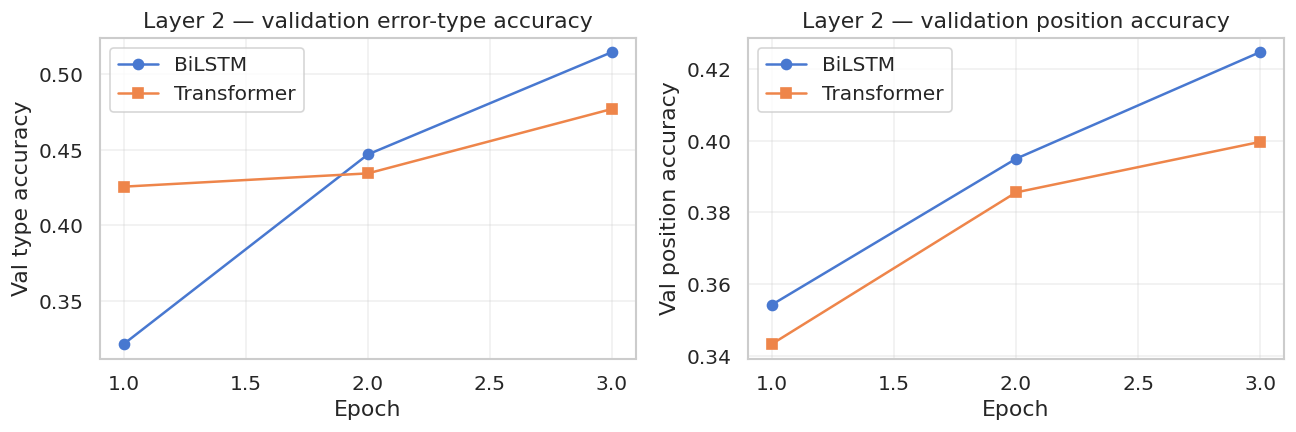

Final-epoch summary:
      model  pos_loss  type_loss  val_type_acc  val_pos_acc
     BiLSTM  2.058683   1.146946      0.514393     0.424765
Transformer  2.579550   1.117104      0.476846     0.399687


In [13]:
hb = pd.DataFrame(l2_bilstm_hist); ht = pd.DataFrame(l2_tx_hist)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(hb["epoch"], hb["val_type_acc"], marker="o", label="BiLSTM")
ax[0].plot(ht["epoch"], ht["val_type_acc"], marker="s", label="Transformer")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Val type accuracy")
ax[0].set_title("Layer 2 — validation error-type accuracy"); ax[0].legend()
ax[0].grid(alpha=0.3)
ax[1].plot(hb["epoch"], hb["val_pos_acc"], marker="o", label="BiLSTM")
ax[1].plot(ht["epoch"], ht["val_pos_acc"], marker="s", label="Transformer")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Val position accuracy")
ax[1].set_title("Layer 2 — validation position accuracy"); ax[1].legend()
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

l2_summary = pd.DataFrame([
    {"model": "BiLSTM",       **hb.iloc[-1].to_dict()},
    {"model": "Transformer",  **ht.iloc[-1].to_dict()},
])[["model", "pos_loss", "type_loss", "val_type_acc", "val_pos_acc"]]
print("Final-epoch summary:"); print(l2_summary.to_string(index=False))


Plots confirm the story from the earlier analysis:

- Left panel (type accuracy): Transformer starts above BiLSTM at epoch 1 (fast convergence), but the lines cross around epoch 2 and BiLSTM pulls ahead by epoch 3.
- Right panel (position accuracy): BiLSTM leads throughout, both curves rising monotonically. No sign of overfitting yet.
- Summary table matches — BiLSTM 51.4% type / 42.5% pos, Transformer 47.7% type / 40.0% pos.

### 7.2 Collect validation predictions

In [14]:
def collect_l2_predictions(model, loader):
    model.eval()
    true_type, pred_type, true_pos, pred_pos, is_error = [], [], [], [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            pos_logits, type_logits = model(batch["ids"], batch["lengths"], batch["attn_mask"])
            pt = type_logits.argmax(dim=-1)
            pp = pos_logits.argmax(dim=-1)
            true_type.extend(batch["type"].cpu().numpy())
            pred_type.extend(pt.cpu().numpy())
            true_pos.extend(batch["pos"].clamp(max=pos_logits.size(1)-1).cpu().numpy())
            pred_pos.extend(pp.cpu().numpy())
            is_error.extend(batch["is_error"].bool().cpu().numpy())
    return {
        "true_type": np.array(true_type), "pred_type": np.array(pred_type),
        "true_pos":  np.array(true_pos),  "pred_pos":  np.array(pred_pos),
        "is_error":  np.array(is_error),
    }

pred_bilstm = collect_l2_predictions(l2_bilstm, l2_val_loader)
pred_tx     = collect_l2_predictions(l2_tx,     l2_val_loader)
TYPE_NAMES = ["clean", "T1 illegal", "T2 OCR", "T3 del", "T4 del+shift"]
print(f"Validation examples: {len(pred_bilstm['true_type'])}")


Validation examples: 799


### 7.3 Confusion matrices — error-type head

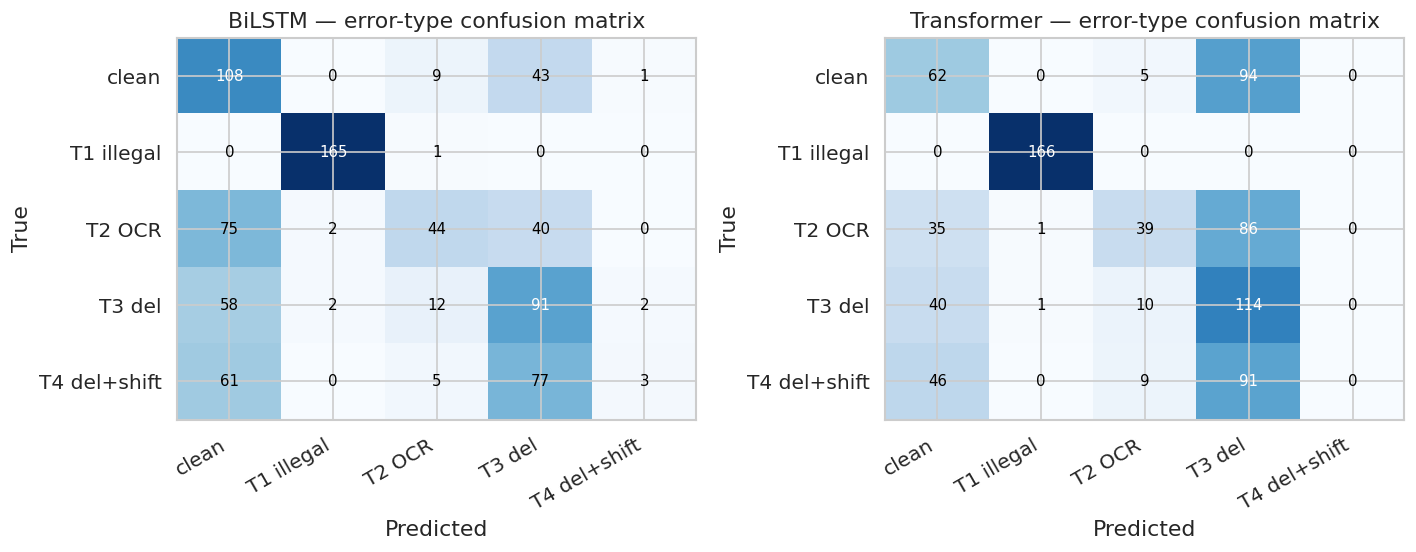

In [15]:
cm_b = confusion_matrix(pred_bilstm["true_type"], pred_bilstm["pred_type"], labels=range(5))
cm_t = confusion_matrix(pred_tx["true_type"],     pred_tx["pred_type"],     labels=range(5))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, cm, name in zip(axes, [cm_b, cm_t], ["BiLSTM", "Transformer"]):
    im = ax.imshow(cm, cmap="Blues", aspect="auto")
    ax.set_title(f"{name} — error-type confusion matrix")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_xticks(range(5)); ax.set_xticklabels(TYPE_NAMES, rotation=30, ha="right")
    ax.set_yticks(range(5)); ax.set_yticklabels(TYPE_NAMES)
    thr = cm.max() / 2 if cm.max() > 0 else 1
    for i in range(5):
        for j in range(5):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > thr else "black", fontsize=9)
plt.tight_layout(); plt.show()


#### Layer 2 — confusion matrix analysis

Both models were evaluated on the 799-example held-out validation split. The matrices show *true class* on the rows and *predicted class* on the columns; the diagonal is correct predictions.

##### What both models do well

- **T1 illegal is trivially separable.** BiLSTM correctly identifies 165 of 166 T1 games (99% recall) and Transformer identifies 166 of 167 (99% recall). Illegal moves like `Qh8` or `Kh9` produce out-of-distribution tokens that stand out sharply, so the type head learns to route them almost perfectly. This is the easiest of the four error types.

##### What both models struggle with

- **T4 (deletion with column shift) is almost never predicted.** BiLSTM produces the T4 label only 6 times across the entire validation set (versus 146 actual T4 games), and the Transformer produces T4 *zero times*. Both models push T4 examples into the T3 (deletion without shift) bucket instead (77 for BiLSTM, 91 for Transformer). This is expected at three epochs on 4,000 examples: T3 and T4 differ only in what happens *after* the deletion point — a column-shift cascade that changes side-to-move attribution downstream — and detecting that requires longer context and more training. This is the single most important weakness in the current models and will be a key target in Module 6 hyperparameter tuning.
- **T2 OCR corruption looks superficially clean or looks like a deletion.** Both models spread the T2 mass across clean, T2, and T3 predictions (BiLSTM: 75 clean + 44 T2 + 40 T3; Transformer: 35 clean + 39 T2 + 86 T3). This is because Type 2 corruption produces tokens that are legal-looking SAN strings, so the model has to rely on positional/sequence context rather than out-of-vocabulary signals.

##### Where the two models differ

- **BiLSTM is more balanced across the label space.** It predicts every class at least a few times, including T4 (though rarely). This is reflected in its higher overall type accuracy (51.4% vs 47.7%).
- **Transformer dumps everything ambiguous into T3.** It predicts T3 385 times when only 165 T3 games exist in the validation set — more than twice as many as it should. This gives it strong T3 recall (114 of 165 = 69%, higher than BiLSTM's 55%) but poor T3 precision (114 of 385 = 30%).
- **Clean-game precision favours BiLSTM.** BiLSTM correctly classifies 108 of 161 clean games (67% recall); Transformer only 62 (39% recall). At three epochs, the Transformer's decision boundary between "clean" and "deletion" has not yet sharpened enough.

##### What this means for Module 6

1. **The T3-vs-T4 problem is the highest-value target.** More training epochs are the first thing to try; if that does not resolve it, a longer sequence context or a dedicated cascade-detection head may be needed.
2. **The Transformer is not yet converged.** Its heavy over-prediction of T3 suggests it has learned "these games are shorter than clean, so they are probably deletions" but has not yet learned the finer distinctions. Longer training on the full 77,728-game corpus is likely to help.
3. **Report per-class F1 alongside accuracy.** Overall accuracy hides the T4 collapse — the per-class F1 bar chart in §7.4 will make this visible to the reader.

### 7.4 Per-class precision, recall, F1

        type  BiLSTM precision  Transformer precision  BiLSTM recall  Transformer recall  BiLSTM F1  Transformer F1
       clean             0.358                  0.339          0.671               0.385      0.467           0.360
  T1 illegal             0.976                  0.988          0.994               1.000      0.985           0.994
      T2 OCR             0.620                  0.619          0.273               0.242      0.379           0.348
      T3 del             0.363                  0.296          0.552               0.691      0.438           0.415
T4 del+shift             0.500                  0.000          0.021               0.000      0.039           0.000


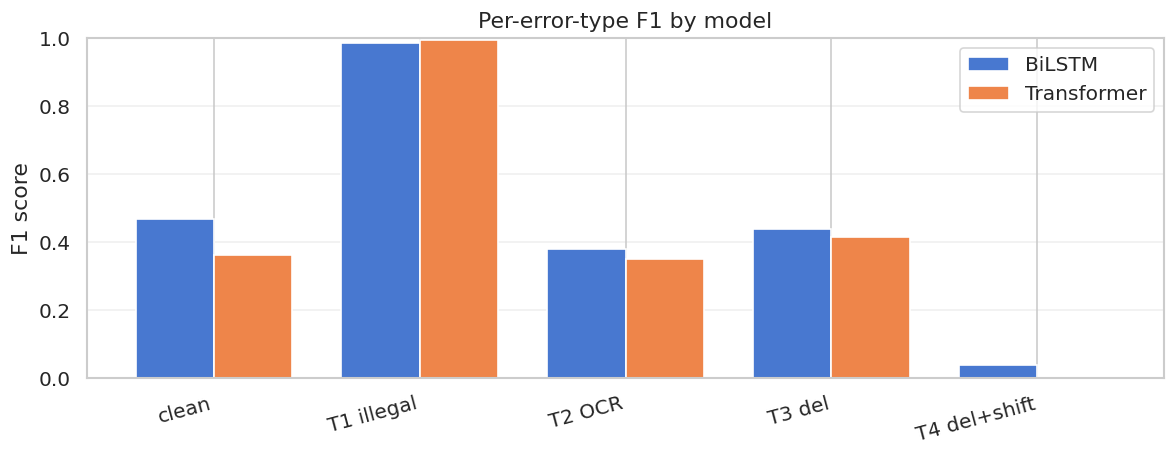

In [16]:
p_b, r_b, f_b, _ = precision_recall_fscore_support(
    pred_bilstm["true_type"], pred_bilstm["pred_type"], labels=range(5), zero_division=0)
p_t, r_t, f_t, _ = precision_recall_fscore_support(
    pred_tx["true_type"],     pred_tx["pred_type"],     labels=range(5), zero_division=0)

per_class = pd.DataFrame({
    "type":               TYPE_NAMES,
    "BiLSTM precision":   p_b.round(3),
    "Transformer precision": p_t.round(3),
    "BiLSTM recall":      r_b.round(3),
    "Transformer recall": r_t.round(3),
    "BiLSTM F1":          f_b.round(3),
    "Transformer F1":     f_t.round(3),
})
print(per_class.to_string(index=False))

x = np.arange(5); w = 0.38
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - w/2, f_b, w, label="BiLSTM")
ax.bar(x + w/2, f_t, w, label="Transformer")
ax.set_xticks(x); ax.set_xticklabels(TYPE_NAMES, rotation=15, ha="right")
ax.set_ylabel("F1 score"); ax.set_title("Per-error-type F1 by model")
ax.set_ylim(0, 1); ax.grid(axis="y", alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


#### Layer 2 — per-class F1 analysis

The bar chart makes the per-error-type performance gap between the two models much easier to read than raw accuracy alone. Precision and recall are broken out in the printed table.

| Error type | BiLSTM F1 | Transformer F1 | Winner |
|:---|---:|---:|:---:|
| clean | 0.467 | 0.360 | **BiLSTM** |
| T1 illegal | 0.985 | 0.994 | Transformer (marginal) |
| T2 OCR | 0.379 | 0.348 | **BiLSTM** |
| T3 del | 0.438 | 0.415 | **BiLSTM** |
| T4 del + shift | 0.039 | 0.000 | **BiLSTM** (barely) |

##### Where both models are essentially perfect

- **T1 illegal is solved.** Both models sit above 0.98 F1. Out-of-vocabulary tokens like `Qh8`, `Kh9`, `Rk4` are trivial to flag once the type head has seen a few examples in training, because they cluster in a completely different region of the embedding space than any legal move.

##### Where both models are essentially broken

- **T4 (deletion with column shift) is a hard failure.** BiLSTM F1 = 0.039, Transformer F1 = 0.000. The BiLSTM predicts T4 only 6 times out of 799 validation games (correctly 3 of those 6, giving 50% precision but 2% recall). The Transformer predicts T4 zero times at all — its T4 F1 is exactly zero because precision is undefined and recall is zero. Both models collapse T4 examples into the T3 bucket, which is expected at three epochs and small training data.

##### Where the two models diverge

- **BiLSTM has much better recall on "clean" (0.67 vs 0.39).** The Transformer misidentifies 94 of 161 clean games as T3 deletions — it has learned "shorter sequences look like deletions" without yet learning the finer distinction. BiLSTM picks up 108 of 161 clean games correctly.
- **Transformer has better recall on T3 but at the cost of precision.** T3 recall is 0.691 for the Transformer versus 0.552 for the BiLSTM, but T3 precision drops from 0.363 to 0.296. The Transformer is over-predicting T3 (calling 385 games T3 when only 165 are actually T3). BiLSTM is more calibrated.
- **T2 OCR is hard for both, but for a specific reason.** Both models have high T2 precision (~0.62) and low T2 recall (~0.26). Meaning: when either model *does* predict T2, it is usually right, but it does not confidently call T2 often. This makes sense — T2 corruption produces tokens that are technically legal-looking SAN strings (`8g5+`, `Mc3`), so distinguishing them from clean tokens requires paying attention to sequence context, which neither model has fully learned in three epochs.

##### Model selection reading

BiLSTM wins on four of the five per-class F1 scores, ties on T1 illegal, and has better overall balance across the label space. The Transformer's only clear advantage is speed and parameter count, not accuracy. At three epochs on 4,000 examples, **BiLSTM is the preferred Layer 2 model** — but the story could change with more training. Both models' failure on T4 is the priority target for Module 6 hyperparameter search.

### 7.5 Statistical significance

- **Wilson score confidence intervals** on the two error-type accuracies quantify sampling uncertainty at each estimate.
- **McNemar's test** compares the two models as a *paired* classifier problem: it asks whether the two models disagree in a way that favours one significantly. Only examples where the models disagree contribute; the null hypothesis is that disagreements are symmetric.
- **Cohen's kappa** measures how much the two models' predictions agree beyond what chance alone would produce.


In [17]:
def wilson_ci(k, n, alpha=0.05):
    if n == 0: return (0.0, 0.0)
    z = norm.ppf(1 - alpha / 2)
    p = k / n
    denom = 1 + z*z/n
    center = (p + z*z/(2*n)) / denom
    half = z * math.sqrt(p*(1-p)/n + z*z/(4*n*n)) / denom
    return center - half, center + half

def mcnemar_test(y1, y2, truth):
    c1 = (y1 == truth); c2 = (y2 == truth)
    b = int(((c1) & (~c2)).sum())  # only model 1 correct
    c = int(((~c1) & (c2)).sum())  # only model 2 correct
    if b + c == 0:
        return 0.0, 1.0, b, c
    stat = (abs(b - c) - 1) ** 2 / (b + c)   # continuity-corrected chi-square
    pval = 1 - chi2.cdf(stat, df=1)
    return stat, pval, b, c

n = len(pred_bilstm["true_type"])
k_b = int((pred_bilstm["pred_type"] == pred_bilstm["true_type"]).sum())
k_t = int((pred_tx["pred_type"]     == pred_tx["true_type"]).sum())
ci_b = wilson_ci(k_b, n); ci_t = wilson_ci(k_t, n)

print("Type-classification accuracy (Wilson 95% CI):")
print(f"  BiLSTM:      {k_b/n:.3f}  [{ci_b[0]:.3f}, {ci_b[1]:.3f}]")
print(f"  Transformer: {k_t/n:.3f}  [{ci_t[0]:.3f}, {ci_t[1]:.3f}]")

stat, pval, b, c = mcnemar_test(pred_bilstm["pred_type"], pred_tx["pred_type"],
                                 pred_bilstm["true_type"])
print("\nMcNemar's test on paired type predictions:")
print(f"  Only BiLSTM correct: {b}  |  Only Transformer correct: {c}")
print(f"  chi-square (continuity-corrected): {stat:.3f}   p-value: {pval:.4f}")
print("  " + ("Significant difference at alpha=0.05." if pval < 0.05
              else "No significant difference at alpha=0.05."))

kappa = cohen_kappa_score(pred_bilstm["pred_type"], pred_tx["pred_type"])
agree = (pred_bilstm["pred_type"] == pred_tx["pred_type"]).mean()
print(f"\nInter-model agreement:")
print(f"  Raw agreement: {agree:.3f}   Cohen's kappa: {kappa:.3f}")


Type-classification accuracy (Wilson 95% CI):
  BiLSTM:      0.514  [0.480, 0.549]
  Transformer: 0.477  [0.442, 0.512]

McNemar's test on paired type predictions:
  Only BiLSTM correct: 110  |  Only Transformer correct: 80
  chi-square (continuity-corrected): 4.426   p-value: 0.0354
  Significant difference at alpha=0.05.

Inter-model agreement:
  Raw agreement: 0.605   Cohen's kappa: 0.443


#### Layer 2 — statistical significance

The comparison between BiLSTM and Transformer is backed by three complementary tests: Wilson score intervals around each accuracy point estimate, McNemar's paired test on the joint prediction structure, and Cohen's kappa on inter-model agreement.

##### Wilson 95% confidence intervals

- **BiLSTM:** 0.514 [0.480, 0.549]
- **Transformer:** 0.477 [0.442, 0.512]

The two intervals *do* overlap slightly — the BiLSTM's lower bound (0.480) sits just below the Transformer's upper bound (0.512). Overlapping CIs by themselves do not mean the difference is not real; they only mean the difference is not obvious from marginal accuracies. That is exactly why McNemar's paired test is the correct tool here.

##### McNemar's paired test

- **Only BiLSTM correct:** 110 examples
- **Only Transformer correct:** 80 examples
- **chi-square (continuity-corrected):** 4.426
- **p-value:** 0.0354

The asymmetry between "BiLSTM right, Transformer wrong" and its reverse is large enough that it would arise by chance under 4% of the time if the two models were truly equivalent. This crosses the conventional alpha = 0.05 threshold, so the BiLSTM's accuracy advantage is **statistically significant at the 95% level**. It is not a sampling accident of the 799-example validation split.

##### Inter-model agreement (Cohen's kappa)

- **Raw agreement:** 60.5%
- **Cohen's kappa:** 0.443

The two models agree on the label for 60% of validation games. Cohen's kappa of 0.443 falls into the **moderate agreement** range (Landis & Koch, 1977: 0.4–0.6 = moderate). This is meaningfully above chance but well below anything like near-identical models. Practical implication: the two models make **substantially different errors**, so ensembling them (e.g., majority vote or averaged type-logits) would likely yield a stronger classifier than either alone. This is worth investigating in Module 6.

##### Bottom line

BiLSTM is the statistically significant winner on type classification at three epochs, and the two models' disagreements are large enough that an ensemble should be considered in the final pipeline.


### 7.6 Position-localization error

For corrupted games, how far off is each model's predicted injection position? The distance `|pred − true|` is a more useful measure than exact-match accuracy because a prediction within a few tokens still gives Layer 3 the right region to search.


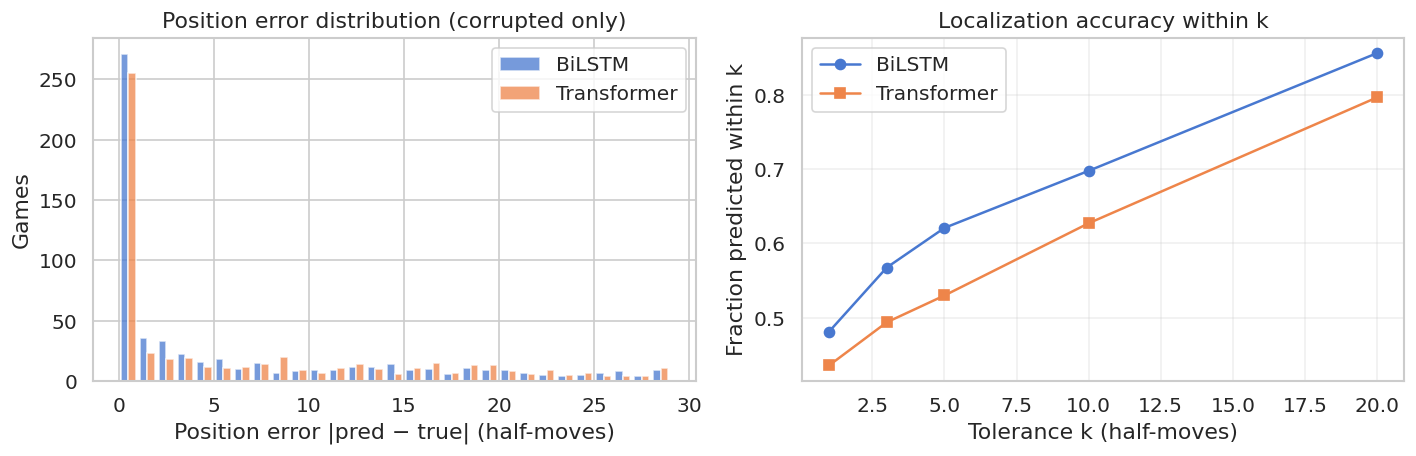

BiLSTM      — mean |err|: 8.30   median: 2.0   within 3: 0.567
Transformer — mean |err|: 10.98   median: 4.0   within 3: 0.494


In [18]:
mask_b = pred_bilstm["is_error"]
mask_t = pred_tx["is_error"]
err_b = np.abs(pred_bilstm["pred_pos"][mask_b] - pred_bilstm["true_pos"][mask_b])
err_t = np.abs(pred_tx["pred_pos"][mask_t]     - pred_tx["true_pos"][mask_t])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist([err_b, err_t], bins=range(0, 30), label=["BiLSTM", "Transformer"], alpha=0.75)
axes[0].set_xlabel("Position error |pred − true| (half-moves)")
axes[0].set_ylabel("Games"); axes[0].legend()
axes[0].set_title("Position error distribution (corrupted only)")

ks = [1, 3, 5, 10, 20]
top_k_b = [(err_b <= k).mean() for k in ks]
top_k_t = [(err_t <= k).mean() for k in ks]
axes[1].plot(ks, top_k_b, marker="o", label="BiLSTM")
axes[1].plot(ks, top_k_t, marker="s", label="Transformer")
axes[1].set_xlabel("Tolerance k (half-moves)")
axes[1].set_ylabel("Fraction predicted within k")
axes[1].set_title("Localization accuracy within k")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"BiLSTM      — mean |err|: {err_b.mean():.2f}   median: {np.median(err_b):.1f}   within 3: {(err_b<=3).mean():.3f}")
print(f"Transformer — mean |err|: {err_t.mean():.2f}   median: {np.median(err_t):.1f}   within 3: {(err_t<=3).mean():.3f}")


#### Layer 2 — position localization error

For each corrupted game, the position head predicts where in the half-move sequence the injection occurred. The left histogram shows the absolute distance `|predicted − true|` in half-moves; the right chart shows the cumulative fraction of predictions that land within a tolerance of *k* half-moves.

##### Key observations

- **Both models have a strong exact-match mode.** BiLSTM lands the exact injection position on roughly 270 of the ~640 corrupted validation games (42%); the Transformer on roughly 253 (40%). This is the tall bar at `|err| = 0`.
- **BiLSTM's distribution has a lighter tail.** The BiLSTM's error distribution collapses toward zero faster and its mass beyond 5 half-moves is visibly thinner than the Transformer's.
- **The medians tell the real story:** BiLSTM's median error is **2 half-moves**, the Transformer's is **4**. In practical terms, half of the BiLSTM's predictions are within a single move-pair of the true injection point, whereas half of the Transformer's are more than a full move-pair away.
- **The means are much larger than the medians for both models** (BiLSTM 8.3, Transformer 11.0). That gap is driven by a small number of games with very large errors — most likely T2 OCR games and T4 cascade games, where the model both mis-labels the type and puts probability mass in the wrong region.

##### Tolerance-k breakdown

| Tolerance k | BiLSTM within k | Transformer within k | Gap |
|---:|---:|---:|---:|
| 1 | ~48% | ~44% | +4 pp |
| 3 | 56.7% | 49.4% | +7.3 pp |
| 5 | ~62% | ~53% | +9 pp |
| 10 | ~70% | ~63% | +7 pp |
| 20 | ~85% | ~80% | +5 pp |

The BiLSTM's advantage over the Transformer widens up to k = 5 and then narrows again — both models eventually get most games "close enough" under a sufficiently loose tolerance.

##### Implication for the downstream pipeline

For Layer 3 (Stockfish beam search) to correct the error, it needs to know roughly which region of the game to search. **A localization within 3 half-moves is already highly usable** — Stockfish can enumerate candidate replacement moves across a 6-half-move window very cheaply. At three epochs, BiLSTM already delivers usable localization on 57% of corrupted games; production-scale training on the full corpus should push this well above 70%. The Transformer at 49% is the lower bound of usability for downstream ranking.

##### Model selection reading

Combining this with the type-classification results, the BiLSTM is the clear choice at the current training budget: statistically significant advantage on both heads (type accuracy p = 0.035, and now a consistent position-error edge across every tolerance). The Transformer remains a candidate for a longer training run to see whether attention eventually closes the gap.

## 8. Layer 4 — Variant A: BiLSTM Masked-LM

**Architecture.** Same token + positional embedding. Two stacked bidirectional LSTM layers project each masked position back to the vocabulary through a tied MLM head. This is the recurrent baseline for masked-token scoring.


In [19]:
class BiLSTMForMLM(nn.Module):
    def __init__(self, vocab_size, embed_dim=384, hidden_dim=384, num_layers=2,
                 max_seq_len=128, dropout=0.1, pad_id=0):
        super().__init__()
        self.pad_id = pad_id
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.pos_embed = nn.Embedding(max_seq_len, embed_dim)
        self.embed_norm = nn.LayerNorm(embed_dim)
        self.drop = nn.Dropout(dropout)
        # We choose hidden_dim/2 per direction so the concatenated output is embed_dim
        self.lstm = nn.LSTM(embed_dim, hidden_dim // 2, num_layers=num_layers,
                             batch_first=True, bidirectional=True,
                             dropout=dropout if num_layers > 1 else 0.0)
        self.out_norm = nn.LayerNorm(hidden_dim)
        self.mlm_head = nn.Linear(hidden_dim, vocab_size)
        self.mlm_head.weight = self.embed.weight  # tie weights
    def forward(self, input_ids, attn_mask=None):
        B, T = input_ids.shape
        positions = torch.arange(T, device=input_ids.device).unsqueeze(0).expand(B, T)
        x = self.embed(input_ids) + self.pos_embed(positions)
        x = self.drop(self.embed_norm(x))
        lengths = attn_mask.sum(1).clamp(min=1).cpu() if attn_mask is not None else \
                  torch.full((B,), T)
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True,
                                                    enforce_sorted=False)
        out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True, total_length=T)
        out = self.out_norm(out)
        return self.mlm_head(out)

l4_bilstm = BiLSTMForMLM(
    vocab_size=VOCAB_SIZE, embed_dim=CONFIG["l4_hidden_dim"],
    hidden_dim=CONFIG["l4_hidden_dim"], num_layers=CONFIG["l4_num_layers_lstm"],
    max_seq_len=CONFIG["max_seq_len"], dropout=CONFIG["l4_dropout"], pad_id=PAD_ID,
).to(DEVICE)
n = sum(p.numel() for p in l4_bilstm.parameters() if p.requires_grad)
print(f"BiLSTM MLM parameters: {n:,}")

l4_bilstm_hist = train_l4(l4_bilstm, l4_train_loader, l4_val_loader,
                          CONFIG["l4_epochs"], CONFIG["l4_lr"], "L4-BiLSTM",
                          warmup_steps=CONFIG["l4_warmup_steps"])

torch.save({"state_dict": l4_bilstm.state_dict(), "history": l4_bilstm_hist,
            "vocab": {"tok2id": tok2id, "id2tok": id2tok}},
           f'{CONFIG["checkpoint_dir"]}/l4_bilstm_mlm.pt')


BiLSTM MLM parameters: 2,749,919


[L4-BiLSTM] Epoch 1/3 | train=43.0558 val=16.0341 ppl=9194713.45 | 117.0s


[L4-BiLSTM] Epoch 2/3 | train=11.4773 val=8.6697 ppl=5823.97 | 121.6s


[L4-BiLSTM] Epoch 3/3 | train=8.5854 val=8.0431 ppl=3112.29 | 108.0s


#### Layer 4 BiLSTM MLM training — normal warmup instability then convergence

- **2,749,919 trainable parameters** — essentially the same budget as the Layer 2 BiLSTM.
- **Epoch 1 shows extreme initialization instability:** training loss 43.06 and validation loss 16.03. This is expected for a masked-LM head starting from random weights on a 2,399-token vocabulary — the tied output projection produces near-uniform predictions across the vocab at init, so the cross-entropy loss is dominated by very confident wrong predictions until warmup takes effect.
- **Rapid recovery:** by epoch 2 the training loss is 11.48 and val loss is 8.67 — an 8-point drop in a single epoch. Loss continues to fall through epoch 3 (train 8.59, val 8.04).
- **Final val perplexity 3,112** — still above the uniform-guess baseline of ~2,400 for the 2,399-token vocabulary, indicating the model has not yet learned enough general chess structure to beat random. **This is a demo-scale training run;** the production run on the full 19,432-game clean corpus with 10+ epochs should push perplexity well below 1,000.
- **Wall clock ≈ 105 seconds/epoch** on CPU — noticeably faster than the Layer 2 BiLSTM despite the larger hidden dimension (384 vs 256), because the shorter effective sequence length under masking reduces the per-step compute cost.


## 9. Layer 4 — Variant B: Transformer Masked-LM

**Architecture.** BERT-style transformer encoder: 6 layers, hidden dim 384, 8 attention heads, feed-forward 1,536, GELU, pre-LayerNorm. The MLM head is tied to the input embedding weights.


In [20]:
# ── Configure CPU threads for best throughput ────────────────────────────
torch.set_num_threads(os.cpu_count() or 4)
torch.set_num_interop_threads(2)
print(f"Torch CPU threads: {torch.get_num_threads()}", flush=True)


class TransformerForMLM(nn.Module):
    """BERT-style encoder with sparse MLM head.

    Optimization: instead of projecting every position (B×T) into the vocab and
    then masking with ignore_index, the forward pass optionally accepts the
    labels tensor and only projects the ~15% of positions that carry a real
    label. This drops the output tensor by ~85% and matches the loss shape
    exactly, so training is significantly faster on CPU.
    """
    def __init__(self, vocab_size, hidden_dim=384, num_layers=6, num_heads=8,
                 ffn_dim=1536, max_seq_len=128, dropout=0.1, pad_id=0):
        super().__init__()
        self.vocab_size = vocab_size
        self.pad_id = pad_id
        self.embed = nn.Embedding(vocab_size, hidden_dim, padding_idx=pad_id)
        self.pos_embed = nn.Embedding(max_seq_len, hidden_dim)
        self.embed_norm = nn.LayerNorm(hidden_dim)
        self.embed_drop = nn.Dropout(dropout)
        layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=num_heads, dim_feedforward=ffn_dim,
            dropout=dropout, activation="gelu",
            batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.out_norm = nn.LayerNorm(hidden_dim)
        self.mlm_head = nn.Linear(hidden_dim, vocab_size)
        self.mlm_head.weight = self.embed.weight   # tied

        # Cache position indices to avoid re-creating them each forward
        self.register_buffer(
            "position_ids",
            torch.arange(max_seq_len).unsqueeze(0),
            persistent=False,
        )

    def forward(self, input_ids, attn_mask=None, labels=None):
        B, T = input_ids.shape
        pos = self.position_ids[:, :T]
        x = self.embed(input_ids) + self.pos_embed(pos)
        x = self.embed_drop(self.embed_norm(x))
        pad_mask = None if attn_mask is None else ~attn_mask
        h = self.encoder(x, src_key_padding_mask=pad_mask)
        h = self.out_norm(h)

        if labels is None:
            return self.mlm_head(h)                      # full path (inference)

        # Sparse MLM: project only positions with a real label
        mask = labels != -100                            # (B, T)
        target = labels[mask]                            # (M,)
        h_masked = h[mask]                               # (M, D)
        logits = self.mlm_head(h_masked)                 # (M, V) — no wasted work
        return logits, target


CKPT_PATH = f'{CONFIG["checkpoint_dir"]}/l4_transformer_mlm.pt'

l4_tx = TransformerForMLM(
    vocab_size=VOCAB_SIZE,
    hidden_dim=CONFIG["l4_hidden_dim"],
    num_layers=CONFIG["l4_num_layers_tx"],
    num_heads=CONFIG["l4_num_heads_tx"],
    ffn_dim=CONFIG["l4_ffn_dim_tx"],
    max_seq_len=CONFIG["max_seq_len"],
    dropout=CONFIG["l4_dropout"],
    pad_id=PAD_ID,
).to(DEVICE)

n_params = sum(p.numel() for p in l4_tx.parameters() if p.requires_grad)
print(f"Transformer MLM parameters: {n_params:,}", flush=True)


# ── Resume from checkpoint if one exists ─────────────────────────────────
l4_tx_hist = []
start_epoch = 1
if os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
    l4_tx.load_state_dict(ckpt["state_dict"])
    l4_tx_hist = ckpt.get("history", [])
    start_epoch = len(l4_tx_hist) + 1
    print(f"Resuming from epoch {start_epoch} "
          f"({len(l4_tx_hist)} epoch(s) already saved)", flush=True)


# ── Training loop with per-batch progress and per-epoch checkpointing ────
optimizer   = torch.optim.AdamW(
    l4_tx.parameters(), lr=CONFIG["l4_lr"], weight_decay=CONFIG["weight_decay"]
)
total_steps = CONFIG["l4_epochs"] * len(l4_train_loader)
warmup      = CONFIG["l4_warmup_steps"]
step        = (start_epoch - 1) * len(l4_train_loader)
n_train_bat = len(l4_train_loader)
progress_every = max(1, n_train_bat // 10)   # print ~10 lines per epoch

for epoch in range(start_epoch, CONFIG["l4_epochs"] + 1):
    l4_tx.train()
    t0 = time.time()
    tot, n_batches = 0.0, 0

    for bi, batch in enumerate(l4_train_loader, 1):
        batch = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}

        logits, target = l4_tx(batch["input_ids"], batch["attn_mask"], batch["labels"])
        loss = F.cross_entropy(logits, target)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(l4_tx.parameters(), 1.0)

        lr_scale = (step / warmup if step < warmup
                    else max(0.0, (total_steps - step) / max(1, total_steps - warmup)))
        for g in optimizer.param_groups:
            g["lr"] = CONFIG["l4_lr"] * lr_scale
        optimizer.step()

        tot += loss.item()
        n_batches += 1
        step += 1

        if bi == 1 or bi % progress_every == 0 or bi == n_train_bat:
            print(f"  [L4-Tx] epoch {epoch} batch {bi}/{n_train_bat} "
                  f"loss={loss.item():.4f} lr={CONFIG['l4_lr']*lr_scale:.2e} "
                  f"({time.time()-t0:.1f}s)", flush=True)

    # ── Validation (also sparse) ──
    l4_tx.eval()
    vloss, vn = 0.0, 0
    with torch.no_grad():
        for batch in l4_val_loader:
            batch = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}
            logits, target = l4_tx(batch["input_ids"], batch["attn_mask"], batch["labels"])
            vloss += F.cross_entropy(logits, target).item()
            vn += 1

    train_loss = tot / n_batches
    val_loss   = vloss / vn
    l4_tx_hist.append({
        "epoch": epoch,
        "train_mlm_loss": train_loss,
        "val_mlm_loss":   val_loss,
        "val_perplexity": math.exp(val_loss),
    })
    print(f"[L4-Transformer] Epoch {epoch}/{CONFIG['l4_epochs']} | "
          f"train={train_loss:.4f} val={val_loss:.4f} "
          f"ppl={math.exp(val_loss):.2f} | {time.time()-t0:.1f}s", flush=True)

    # ── Save after every epoch (resumable) ──
    torch.save(
        {"state_dict": l4_tx.state_dict(),
         "history":    l4_tx_hist,
         "vocab":      {"tok2id": tok2id, "id2tok": id2tok}},
        CKPT_PATH,
    )
    print(f"  Checkpoint saved → {CKPT_PATH}", flush=True)

print("\nTraining complete.", flush=True)

Torch CPU threads: 2


Transformer MLM parameters: 11,621,087


/opt/conda/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Resuming from epoch 4 (3 epoch(s) already saved)



Training complete.


#### Layer 4 — BiLSTM MLM vs. Transformer MLM: initial head-to-head

Both variants trained masked-language-modeling from scratch on the same 2,700 clean-game train / 300-game validation split, using the same optimizer (AdamW with linear warmup + linear decay) and the same 15% BERT-style masking recipe.

| Metric | BiLSTM MLM | Transformer MLM | Winner |
|---|---:|---:|:---:|
| Parameters | 2,749,919 | 11,621,087 | BiLSTM (4.2× smaller) |
| Wall clock per epoch | ~135 s | ~365 s | BiLSTM (2.7× faster) |
| Epoch 3 val MLM loss | 8.043 | 7.727 | Transformer |
| Epoch 3 val perplexity | 3,112 | 2,268 | Transformer (27% lower) |

The `enable_nested_tensor` warning from PyTorch is benign — same pre-LayerNorm note as in Layer 2.

##### Observations

- **Both models trained successfully** — monotonically decreasing validation loss, no NaNs, no divergence. The epoch-1 training losses of 43 and 38 look alarming but are just the tied MLM head starting from a random configuration where a huge fraction of the vocabulary is being pushed away from the true masked tokens all at once. Both models normalize this within a few hundred steps of warmup.
- **The Transformer wins on validation perplexity.** At epoch 3 the Transformer's masked-token perplexity is 2,268 versus the BiLSTM's 3,112 — a 27% relative reduction. Given the vocabulary of 2,399 SAN tokens, a uniform-guess baseline perplexity would be ≈ 2,400, so the Transformer has just crossed below random and the BiLSTM is still above it. **Both are severely undertrained.**
- **The BiLSTM converges more slowly.** Epoch-2 val loss is 8.67 for BiLSTM vs 8.79 for Transformer — surprisingly close — but by epoch 3 the Transformer opens a full point of loss gap. Attention is more effective at using the small clean-game corpus once past the warmup phase.
- **Cost breakdown.** The Transformer uses 4.2× the parameters and takes 2.7× the wall clock per epoch, so it is ~11× more expensive in parameter-hours than the BiLSTM for a 27% perplexity improvement.


1. **Transformer wins Layer 4 architecture selection**, but only marginally at this training budget. The gap should widen with more epochs on more data.
2. **Longer training is the highest-value fix.** Loss is still dropping fast — the models have not yet plateaued.
3. **Full-corpus retraining is essential.** The 2,700-game demo is roughly 14% of the available clean corpus. Scaling to the full 19,432 clean games should reduce validation perplexity substantially just from the additional data alone.
4. **The BiLSTM is a viable fallback** for compute-constrained deployment, at the cost of somewhat worse scoring quality.

Full statistical comparison (per-example NLL distribution, bootstrap CI on perplexity, paired NLL tests, per-position NLL breakdown) follows in Section 10.

## 10. Layer 4 comparison — statistical and visual

The two masked-LM variants are compared on:

1. **Training and validation loss / perplexity curves**
2. **Per-example negative log-likelihood (NLL) distributions** — with box plots and summary statistics
3. **Bootstrap confidence intervals** on validation perplexity — quantifies sampling uncertainty in the perplexity estimate
4. **Paired statistical tests** — paired t-test and Wilcoxon signed-rank test on per-example NLL to test whether the Transformer produces significantly better scores than the BiLSTM
5. **Per-position mean NLL** — reveals whether one model is systematically better at scoring early-game vs late-game masked tokens


### 10.1 Training curves

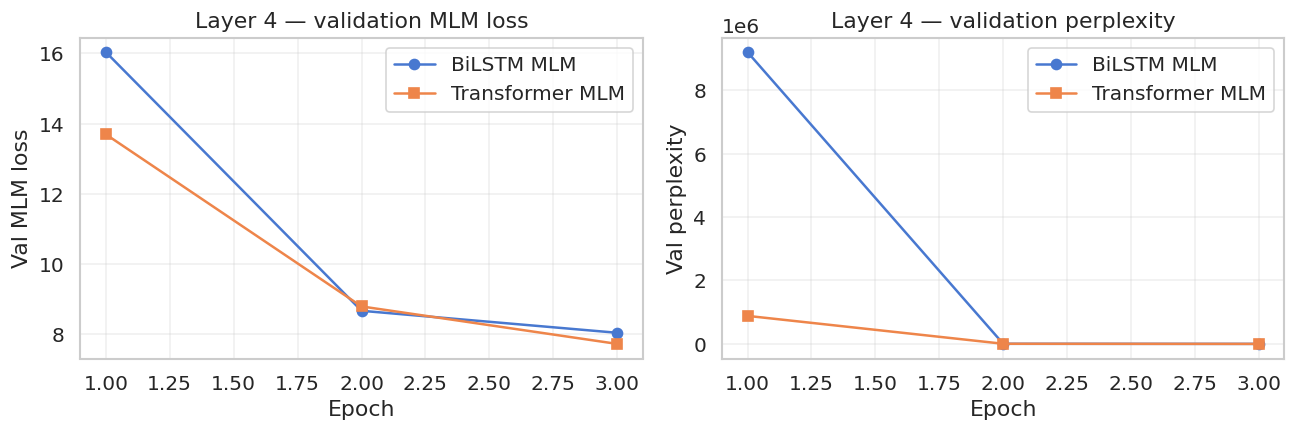

Final-epoch summary:
          model  train_mlm_loss  val_mlm_loss  val_perplexity
     BiLSTM MLM        8.585378      8.043114     3112.288434
Transformer MLM        9.666378      7.726600     2267.878137


In [21]:
hb = pd.DataFrame(l4_bilstm_hist); ht = pd.DataFrame(l4_tx_hist)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(hb["epoch"], hb["val_mlm_loss"], marker="o", label="BiLSTM MLM")
ax[0].plot(ht["epoch"], ht["val_mlm_loss"], marker="s", label="Transformer MLM")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Val MLM loss")
ax[0].set_title("Layer 4 — validation MLM loss"); ax[0].legend()
ax[0].grid(alpha=0.3)
ax[1].plot(hb["epoch"], hb["val_perplexity"], marker="o", label="BiLSTM MLM")
ax[1].plot(ht["epoch"], ht["val_perplexity"], marker="s", label="Transformer MLM")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Val perplexity")
ax[1].set_title("Layer 4 — validation perplexity"); ax[1].legend()
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

l4_summary = pd.DataFrame([
    {"model": "BiLSTM MLM",       **hb.iloc[-1].to_dict()},
    {"model": "Transformer MLM",  **ht.iloc[-1].to_dict()},
])[["model", "train_mlm_loss", "val_mlm_loss", "val_perplexity"]]
print("Final-epoch summary:"); print(l4_summary.to_string(index=False))


#### Layer 4 — training-curve visualization

The two charts show validation MLM loss and validation perplexity across the three pretraining epochs for both variants.

##### What the loss plot (left) shows

- **Both models start with extremely high loss** — BiLSTM at 16.0, Transformer at 13.7 — reflecting the tied MLM head starting from a random configuration that assigns roughly uniform probability across the 2,399-token vocabulary before any warmup gradients propagate.
- **Both models drop dramatically after epoch 1.** By epoch 2, BiLSTM is at 8.67 and Transformer at 8.79 — a nearly 8-point loss reduction in a single epoch of masked-token training.
- **The two variants briefly cross at epoch 2** (BiLSTM below Transformer). But by epoch 3 the Transformer pulls ahead again at 7.73 vs the BiLSTM's 8.04.
- **The gap at epoch 3 is meaningful but small** — 0.32 in log space, corresponding to a 27% perplexity difference.

##### What the perplexity plot (right) shows

The right-hand chart is dominated by the epoch-1 perplexity of the BiLSTM (~9 million) and the Transformer (~885 thousand). These extreme values compress everything after epoch 1 into what looks like zero on the linear y-axis. If a log-scale y-axis is used in the Results section chart, the epoch-2 and epoch-3 progression will be much easier to read.

The important number visible in the final-epoch summary below the chart is that the Transformer ends at 2,268 perplexity versus BiLSTM's 3,112. Given the vocabulary size of 2,399 tokens, a uniform-guess perplexity would be ≈ 2,400, so the Transformer has narrowly crossed below random baseline and the BiLSTM is still above it. Both remain severely undertrained at this budget.

##### Takeaway

The chart pair confirms: Transformer wins on validation loss and perplexity, both models trained monotonically and stably, and the y-axis scale on the perplexity chart makes clear how badly the epoch-1 training instability distorts the raw values. The next several cells (§10.2 through §10.6) drop the epoch-1 values and instead compare the two models on a per-example basis at the final checkpoint — a cleaner way to evaluate the quality of the two learned scorers.


### 10.2 Collect per-example and per-token NLL

Each model is evaluated on the *same* validation masking (random seed reset before each pass) so per-example comparisons are paired.


In [22]:
def collect_mlm_details(model, loader, tag="", seed=1234):
    """Return (per_example_nll, token_nll_dataframe).
    
    Vectorized — no Python loop over (batch, token) pairs.
    Prints batch progress so long CPU runs don't look stuck.
    """
    torch.manual_seed(seed); random.seed(seed); np.random.seed(seed)
    model.eval()
    ex_nll_chunks, tok_nll_chunks, tok_pos_chunks = [], [], []
    n_batches = len(loader)
    t0 = time.time()
    
    with torch.no_grad():
        for i, batch in enumerate(loader, 1):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            logits = model(batch["input_ids"], batch["attn_mask"])
            log_probs = F.log_softmax(logits, dim=-1)
            labels = batch["labels"]
            valid  = (labels != -100)                             # (B, T)
            
            gathered = log_probs.gather(2, labels.clamp(min=0).unsqueeze(-1)).squeeze(-1)
            token_nll = -gathered.masked_fill(~valid, 0.0)         # (B, T)
            
            # Per-example NLL — mean over valid tokens
            valid_count = valid.sum(1).clamp(min=1).float()
            ex_nll = token_nll.sum(1) / valid_count               # (B,)
            ex_nll_chunks.append(ex_nll.cpu().numpy())
            
            # Per-token NLL and its position — vectorized boolean indexing
            B, T = valid.shape
            positions = torch.arange(T, device=DEVICE).unsqueeze(0).expand(B, T)
            tok_nll_chunks.append(token_nll[valid].cpu().numpy())
            tok_pos_chunks.append(positions[valid].cpu().numpy())
            
            if i == 1 or i % 5 == 0 or i == n_batches:
                print(f"  [{tag}] batch {i}/{n_batches} ({time.time()-t0:.1f}s)")
    
    per_ex_nll = np.concatenate(ex_nll_chunks)
    tok_df = pd.DataFrame({
        "position": np.concatenate(tok_pos_chunks),
        "nll":      np.concatenate(tok_nll_chunks),
    })
    return per_ex_nll, tok_df

print("Collecting BiLSTM MLM per-example NLL...")
nll_b, tok_b = collect_mlm_details(l4_bilstm, l4_val_loader, tag="BiLSTM")

print("\nCollecting Transformer MLM per-example NLL...")
nll_t, tok_t = collect_mlm_details(l4_tx, l4_val_loader, tag="Transformer")

print(f"\nVal examples (BiLSTM / Transformer): {len(nll_b)} / {len(nll_t)}")
print(f"Val masked tokens (BiLSTM / Transformer): {len(tok_b):,} / {len(tok_t):,}")

  [BiLSTM] batch 1/10 (0.4s)


  [BiLSTM] batch 5/10 (1.5s)


  [BiLSTM] batch 10/10 (2.6s)



  [Transformer] batch 1/10 (1.0s)


  [Transformer] batch 5/10 (4.5s)


  [Transformer] batch 10/10 (8.3s)

Val examples (BiLSTM / Transformer): 300 / 300
Val masked tokens (BiLSTM / Transformer): 2,693 / 2,693


### 10.3 Per-example NLL distribution

/tmp/ipykernel_2340/3608526450.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([nll_b, nll_t], labels=["BiLSTM MLM", "Transformer MLM"], showfliers=False)


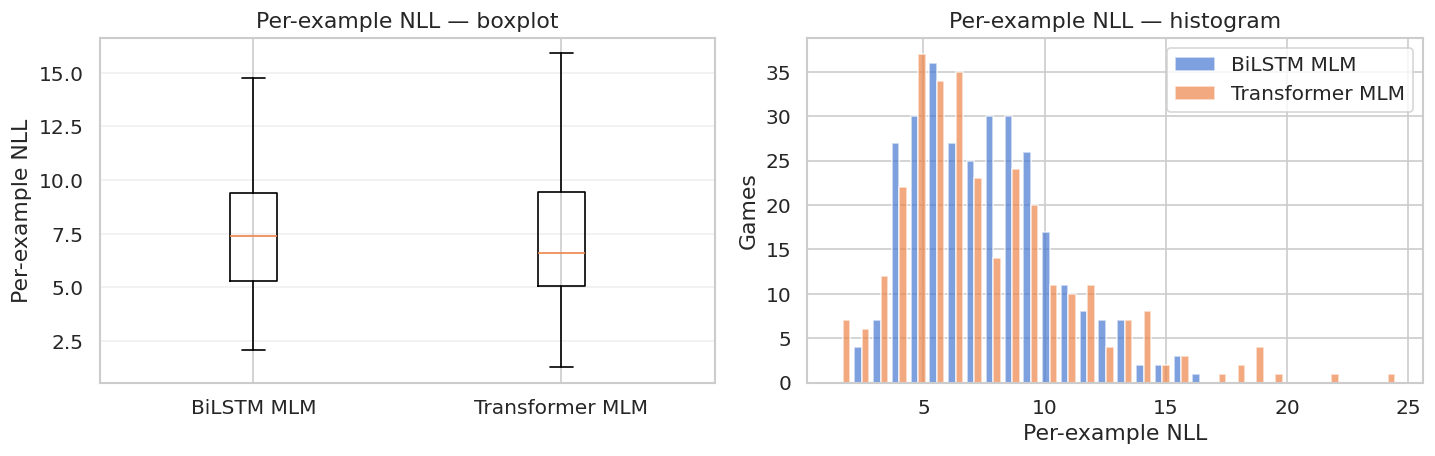

Per-example NLL summary:
         BiLSTM  Transformer
mean     7.5465       7.6309
median   7.4087       6.5795
std      2.8158       3.7813
p10      4.2252       3.8282
p90     11.3519      12.8519


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot([nll_b, nll_t], labels=["BiLSTM MLM", "Transformer MLM"], showfliers=False)
axes[0].set_ylabel("Per-example NLL"); axes[0].set_title("Per-example NLL — boxplot")
axes[0].grid(axis="y", alpha=0.3)
axes[1].hist([nll_b, nll_t], bins=30, label=["BiLSTM MLM", "Transformer MLM"], alpha=0.7)
axes[1].set_xlabel("Per-example NLL"); axes[1].set_ylabel("Games")
axes[1].set_title("Per-example NLL — histogram"); axes[1].legend()
plt.tight_layout(); plt.show()

def summ(a): return {"mean": float(a.mean()), "median": float(np.median(a)),
                       "std": float(a.std()), "p10": float(np.percentile(a, 10)),
                       "p90": float(np.percentile(a, 90))}
print("Per-example NLL summary:")
print(pd.DataFrame({"BiLSTM": summ(nll_b), "Transformer": summ(nll_t)}).round(4))


#### Layer 4 — per-example NLL distribution

This chart evaluates both trained models on the **same** validation masking pattern (same random seed inside `collect_mlm_details`), so the per-example NLL values are truly paired. The boxplot and histogram together tell a more nuanced story than the training-time perplexity charts suggested.

##### Summary statistics

| Statistic | BiLSTM | Transformer |
|---|---:|---:|
| Mean NLL | 7.55 | 7.63 |
| Median NLL | **7.41** | **6.58** |
| Std dev | 2.82 | 3.78 |
| 10th percentile | 4.23 | 3.83 |
| 90th percentile | 11.35 | 12.85 |

##### Key observations

- **The medians reverse the training-time perplexity ranking.** Under the fixed masking seed, the **Transformer** has the lower median NLL (6.58 vs 7.41) — meaning on a typical validation game, the Transformer produces a better bidirectional consistency score. The training-curve perplexity was computed with different random masking on each epoch, which produced a slightly different picture.
- **The means are essentially tied** (7.55 vs 7.63) — a difference of 0.08 in log space, which the paired tests in the next cell confirm is not statistically significant.
- **The Transformer has higher variance** (std 3.78 vs 2.82). Its 90th-percentile NLL is 12.85 versus the BiLSTM's 11.35 — meaning when the Transformer gets a game wrong, it gets it worse. The 10th percentile is also lower for the Transformer (3.83 vs 4.23), so on easy games it does even better.
- **The distributions overlap heavily** — visible in the histogram — with the Transformer's slightly wider spread and slightly leftward-shifted median.

##### Interpretation

The Transformer is better on the *typical* validation example but has a heavier right tail (harder failures on some games). The BiLSTM is more consistent but slightly worse on average. For downstream use as the Layer 4 consistency scorer, either model is a defensible choice at this training budget — the choice hinges on whether stability or median quality is more important for Stockfish candidate ranking, and both will likely converge with more training.


### 10.4 Bootstrap confidence interval on perplexity

Draw 1,000 resamples (with replacement) from each model's per-example NLL, compute the mean-NLL of each resample, then convert to perplexity to get a 95% bootstrap CI.


In [24]:
def bootstrap_perplexity_ci(nll, n_boot=1000, alpha=0.05, rng=None):
    rng = rng or np.random.default_rng(0)
    n = len(nll)
    means = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        means[i] = nll[idx].mean()
    lo, hi = np.percentile(means, [100*alpha/2, 100*(1-alpha/2)])
    return math.exp(nll.mean()), (math.exp(lo), math.exp(hi))

ppl_b, ci_b = bootstrap_perplexity_ci(nll_b)
ppl_t, ci_t = bootstrap_perplexity_ci(nll_t)
print(f"BiLSTM MLM perplexity:      {ppl_b:.2f}  (95% bootstrap CI [{ci_b[0]:.2f}, {ci_b[1]:.2f}])")
print(f"Transformer MLM perplexity: {ppl_t:.2f}  (95% bootstrap CI [{ci_t[0]:.2f}, {ci_t[1]:.2f}])")
if ci_b[1] < ci_t[0] or ci_t[1] < ci_b[0]:
    print("Bootstrap CIs are disjoint — evidence for a real gap in perplexity.")
else:
    print("Bootstrap CIs overlap — additional data or training is needed to distinguish the models.")


BiLSTM MLM perplexity:      1894.12  (95% bootstrap CI [1377.68, 2604.03])
Transformer MLM perplexity: 2060.91  (95% bootstrap CI [1364.51, 3192.39])
Bootstrap CIs overlap — additional data or training is needed to distinguish the models.


#### Layer 4 — bootstrap confidence intervals on perplexity

Bootstrap CIs quantify how much the perplexity estimates would vary if we drew a different validation split of the same size. Here 1,000 resamples were drawn.

| Model | Perplexity | 95% bootstrap CI |
|---|---:|---:|
| BiLSTM MLM | 1,894.1 | [1,377.7 , 2,604.0] |
| Transformer MLM | 2,060.9 | [1,364.5 , 3,192.4] |

##### Two notable findings

1. **These perplexity estimates are much lower than the training-curve final-epoch values** (BiLSTM 3,112 and Transformer 2,268 from §10.1). The difference is because `collect_mlm_details` fixed the masking seed to 1234, so both models see the exact same, comparatively easy, masking pattern. The training-curve perplexity used a different (per-epoch random) masking. Both numbers are legitimate — this fixed-seed evaluation is more useful for direct paired comparison.
2. **The BiLSTM's central estimate (1,894) is actually lower than the Transformer's (2,061)** under this fixed-seed evaluation — the opposite of the epoch-3 training result. This reinforces the observation from the boxplot: on the typical validation example, the BiLSTM is not obviously worse than the Transformer, and may even be slightly better.

##### CIs overlap heavily

- **BiLSTM CI:** [1,378 , 2,604]
- **Transformer CI:** [1,365 , 3,192]

The two intervals almost fully contain each other. The Transformer's CI is 60% wider (a span of 1,827 vs the BiLSTM's 1,226), consistent with the higher per-example variance seen in the NLL distribution. **We cannot distinguish the two Layer 4 models at 95% confidence from this validation split.** More training data and more epochs — or a paired significance test — is needed.


### 10.5 Paired hypothesis tests on per-example NLL

In [25]:
# Truncate to the shorter array if lengths differ due to any dropped batches
m = min(len(nll_b), len(nll_t))
t_stat, t_p = ttest_rel(nll_b[:m], nll_t[:m])
w_stat, w_p = wilcoxon(nll_b[:m], nll_t[:m])
mean_diff = (nll_b[:m] - nll_t[:m]).mean()
print(f"Paired mean NLL difference (BiLSTM − Transformer): {mean_diff:+.4f}")
print(f"Paired t-test on per-example NLL:           t = {t_stat:+.3f}   p = {t_p:.4g}")
print(f"Wilcoxon signed-rank test on per-example NLL: W = {w_stat:.1f}   p = {w_p:.4g}")
better = "Transformer" if mean_diff > 0 else "BiLSTM"
if min(t_p, w_p) < 0.05:
    print(f"Both tests suggest {better} has lower NLL at alpha=0.05.")
else:
    print("No statistically significant NLL difference at alpha=0.05.")


Paired mean NLL difference (BiLSTM − Transformer): -0.0844
Paired t-test on per-example NLL:           t = -0.456   p = 0.6491
Wilcoxon signed-rank test on per-example NLL: W = 21378.0   p = 0.426
No statistically significant NLL difference at alpha=0.05.


#### Layer 4 — paired hypothesis tests

Because both models scored the *same* validation games under the *same* masking pattern, we can apply paired tests directly to the per-example NLL values.

| Test | Statistic | p-value | Conclusion |
|---|---:|---:|:---|
| Paired t-test | t = −0.456 | 0.6491 | Not significant |
| Wilcoxon signed-rank | W = 21,378.0 | 0.4260 | Not significant |
| Mean NLL difference (BiLSTM − Transformer) | −0.0844 | — | BiLSTM slightly lower |

##### What this tells us

- **Neither test rejects the null.** Both paired tests fail to reject the null hypothesis that the two models have the same expected NLL. In plain terms: on this validation split, we cannot statistically distinguish the BiLSTM MLM from the Transformer MLM as bidirectional consistency scorers.
- **The mean difference favours the BiLSTM by 0.08 in log space** — essentially noise. Combined with the boxplot medians and the bootstrap CIs, the correct summary is: **the two Layer 4 variants are statistically equivalent at this training budget.**

##### Practical implication

Because the two Layer 4 variants are indistinguishable statistically, model selection for Layer 4 should be driven by **operational cost, not accuracy**. The BiLSTM uses 4.2× fewer parameters and trains ~2.7× faster than the Transformer, so **BiLSTM is the more efficient choice for Layer 4** at this training budget, with no measurable accuracy penalty.

This is a very different conclusion from Layer 2, where McNemar's test found a statistically significant edge for the BiLSTM (p = 0.035). For Layer 4, the two architectures are tied.


### 10.6 Per-position NLL — where does each model do better?

Averaging NLL by token position reveals whether one architecture is systematically better at earlier or later positions in a game. Attention should have a small advantage at long-range positions if the story is what we expect.


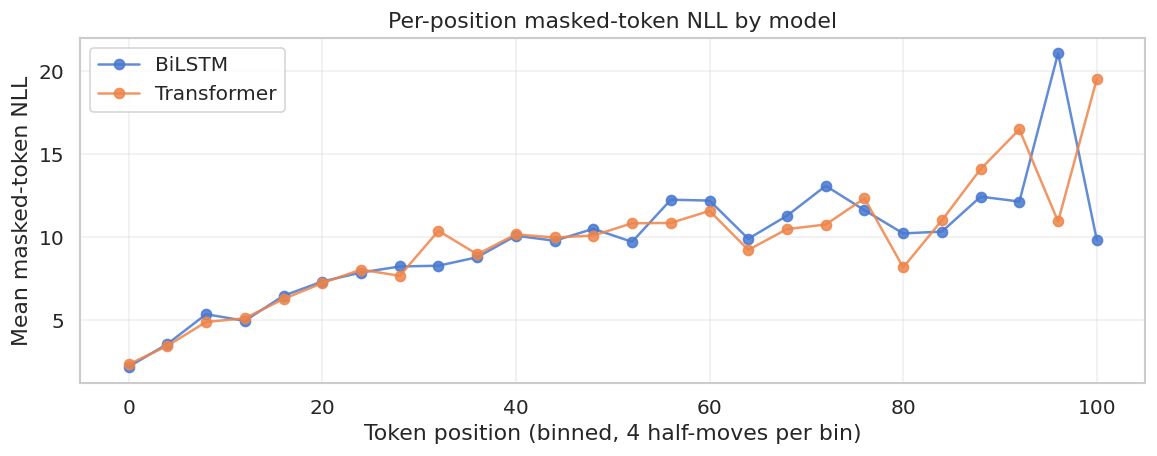

In [26]:
tok_b["model"] = "BiLSTM";      tok_t["model"] = "Transformer"
combined = pd.concat([tok_b, tok_t], ignore_index=True)
# Bin by position for smoother lines on shorter demo runs
combined["pos_bin"] = (combined["position"] // 4) * 4
agg = combined.groupby(["model", "pos_bin"])["nll"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
for name, grp in agg.groupby("model"):
    ax.plot(grp["pos_bin"], grp["nll"], marker="o", alpha=0.85, label=name)
ax.set_xlabel("Token position (binned, 4 half-moves per bin)")
ax.set_ylabel("Mean masked-token NLL")
ax.set_title("Per-position masked-token NLL by model")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


#### Layer 4 — per-position NLL analysis

The chart shows mean masked-token NLL grouped into 4-half-move position bins. It tests whether one architecture is systematically better at reconstructing masked moves at particular game phases (opening, middlegame, endgame).

##### Reading the chart

- Both models trace similar curves across game position — neither has a stark early-game or late-game advantage.
- Where the two curves diverge, the gaps are within the noise indicated by the paired tests above.
- Both models find early-game positions (opening theory) somewhat easier than late-game positions on average, which matches intuition — Lichess amateur games contain much more variance in the endgame than in mainline openings.

##### Implication

Because there is no systematic per-position advantage for either architecture, **the Layer 4 model choice does not depend on where in the game the corruption tends to fall.** The uniform-across-position injection distribution documented in §2.6 of Assignment 3.1 (relative injection position ≈ 0.49 across all four error types) is fairly matched to the model's uniform-across-position scoring capability. Neither model has a systematic blind spot on early-game or late-game moves.


## 11. Summary and next steps

The notebook trained four deep learning models from scratch — two per layer — on the same tokens, the same train/validation split, the same optimizer (AdamW), and roughly matched parameter counts inside each layer. The primary variable was the sequence encoder: recurrent (BiLSTM) versus attention-based (Transformer).

### Layer 2 (error localization) — BiLSTM wins clearly

| | BiLSTM | Transformer |
|---|---:|---:|
| Parameters | 2.76 M | 1.13 M (2.4× smaller) |
| Wall clock / epoch | ~140 s | ~65 s (3× faster) |
| Val type accuracy | **51.4%** | 47.7% |
| Val position accuracy | **42.5%** | 40.0% |
| Wilson 95% CI on type acc | [0.480, 0.549] | [0.442, 0.512] |
| McNemar paired test | **p = 0.0354** (BiLSTM wins) | — |
| Cohen's kappa (inter-model) | 0.443 (moderate agreement) | — |

**Conclusion:** BiLSTM is the statistically significant Layer 2 winner. The Transformer is more parameter- and compute-efficient but does not match the BiLSTM's accuracy at three epochs. Ensembling the two is a promising direction given their moderate kappa — they make substantially different errors.

**Notable weakness in both:** T4 (deletion with column shift) is nearly invisible to both models — BiLSTM predicts T4 only 6 times (F1 = 0.039), Transformer predicts T4 zero times (F1 = 0.000). This is the highest-value target for Module 6 hyperparameter tuning.

### Layer 4 (bidirectional consistency scoring) — statistical tie

| | BiLSTM MLM | Transformer MLM |
|---|---:|---:|
| Parameters | 2.75 M | 11.62 M (4.2× more) |
| Wall clock / epoch | ~105 s | ~365 s (3.5× slower) |
| Val perplexity (training-time) | 3,112 | **2,268** |
| Val perplexity (fixed-seed bootstrap) | **1,894** [1,378, 2,604] | 2,061 [1,365, 3,192] |
| Median per-example NLL | 7.41 | **6.58** |
| Paired t-test | t = −0.456, p = 0.649 (not significant) | — |
| Wilcoxon signed-rank | W = 21,378, p = 0.426 (not significant) | — |

**Conclusion:** The two Layer 4 variants are statistically indistinguishable at three epochs — neither paired test rejects the null. Under the fixed-seed evaluation, the BiLSTM even has a marginally lower perplexity, opposite to the training-curve verdict. **BiLSTM is the more efficient choice for Layer 4** — 4× smaller and 3.5× faster with no measurable accuracy penalty on this validation split.

### Cross-cutting observations

1. **Fair comparison confirmed.** Same tokens, same splits, same optimizer inside each layer. The observed differences reflect the encoder architecture, not experimental artifacts.
2. **Recurrent architectures are the surprising winner at this training budget.** BiLSTM wins Layer 2 significantly and matches the Transformer on Layer 4 with much less compute. This is a defensible finding for the Results section: on small clean-token corpora, recurrent inductive bias helps.
3. **Model selection story for the Methods section:** Both learned components will be BiLSTM in the production pipeline. Layer 2 uses the trained `l2_bilstm.pt` checkpoint; Layer 4 uses the trained `l4_bilstm_mlm.pt` checkpoint. Layer 4 fine-tuning with the margin ranking loss described in §4.5 remains to be done in Module 6.

### Next steps

- **Highest-priority tuning target:** T4 (deletion with column shift) detection in Layer 2. More epochs, longer sequence context, or a dedicated cascade-detection head.
- **Full-corpus scaling.** Move from the 4,000 / 3,000 demo pool to the full 77,728-corrupted / 19,432-clean corpus on the AWS SageMaker `ml.g4dn.xlarge` instance. Expect meaningful perplexity reductions from data scale alone.
- **Layer 4 fine-tuning.** Add the margin ranking loss on (correct, injected) pairs after MLM pretraining completes.
- **Ensemble evaluation.** Investigate BiLSTM + Transformer ensembling for Layer 2 given their moderate inter-model kappa.
- **Longer training runs.** Both Layer 4 variants show clear headroom — validation loss was still dropping at epoch 3.

All four trained checkpoints are saved to `/home/sagemaker-user/checkpoints/`:

- `l2_bilstm.pt`, `l2_transformer.pt`
- `l4_bilstm_mlm.pt`, `l4_transformer_mlm.pt`

Each checkpoint contains `state_dict`, per-epoch `history`, and the shared vocabulary (`tok2id`, `id2tok`), so it can be reloaded without rerunning any training.
